# Complete information-pattern pipeline

This notebook runs the complete simulation pipeline for an ellipsoidal nanoparticle illuminated by a `HermiteGauss00` incident field.

The workflow is:

1. Define the nanoparticle geometry, material, and mass.
2. Define the `HermiteGauss00` incident field using the filling factor.
3. Compute librational information patterns around `x`, `y`, and `z`.
4. Compute center-of-mass information patterns along `x`, `y`, and `z`.
5. Evaluate the maximum detection efficiency for librational and COM motion.
6. Compute optical force and torque curves.
7. Estimate recoil force-noise, trap frequencies, and recoil heating rates.

## General imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

## Repository imports and default configuration

In [ ]:
from info_patterns.parameters import (ELLIPSOID_GEOMETRY_PARAMS, DEFAULT_STEP_NM, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, FAST_FARFIELD_PARAMS, DEFAULT_DYADS_PARAMS, 
                                      DEFAULT_COM_DISPLACEMENT_NM, DEFAULT_LIBRATION_ANGLE_DEG, PLUS_Z_HEMISPHERE_THETA_MAX, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, 
                                      DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL, DEFAULT_FILLING_FACTOR, DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS, DEFAULT_OPTICAL_POWER_W, 
                                      DEFAULT_FREE_SPACE_IMPEDANCE_OHM)

from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material, nanoparticle_mass)
from info_patterns.light_matter_interaction_simulation import (w0_from_filling_factor, hermite_gauss00_power_amplitude_factor, incident_field, field_propagation, scattered_farfield_from_simulation, 
                                                               com_scattered_farfield, librational_scattered_farfield)
from info_patterns.information_patterns_simulation import (info_patterns_from_scattered_field)
from info_patterns.measurement_tools import (max_detection_efficiency, force_vs_displacement, torque_vs_rotation, recoil_force_noise_psd, trap_frequency, heating_rate)
from info_patterns.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns, plot_force_displacement, plot_torque_rotation)
set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "hermite_gauss00_complete_pipeline_results"

## Nanoparticle geometry, material, and mass

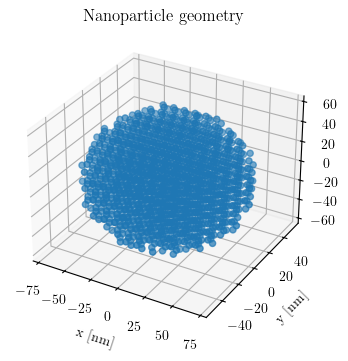

Geometry shape: (1383, 3)
Geometry center: [ 0.0000000e+00 -1.5101567e-06  4.1539652e-06]
Material: <pyGDM2.materials.sio2 object at 0x12d350510>
Mass: 1.935221e-18 kg
step_nm = 10.0


In [ ]:
step_nm = DEFAULT_STEP_NM

geometry_params = ELLIPSOID_GEOMETRY_PARAMS.copy()
geometry_params["step_nm"] = step_nm

geometry = nanoparticle_geometry(**geometry_params)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)
mass = nanoparticle_mass(geometry=geometry, particle_type=geometry_params["particle_type"], step_nm=step_nm, material_name=DEFAULT_MATERIAL_NAME, mesh=geometry_params["mesh"], 
                         method="analytic", R1=geometry_params["R1"], R2=geometry_params["R2"], R3=geometry_params["R3"])

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(geometry[:, 0], geometry[:, 1], geometry[:, 2], s=20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("y [nm]")
ax.set_zlabel("z [nm]")
ax.set_title("Nanoparticle geometry")
plt.show()

print("Geometry shape:", geometry.shape)
print("Geometry center:", np.mean(geometry, axis=0))
print("Material:", material)
print(f"Mass: {mass:.6e} kg")
print(f"step_nm = {step_nm}")

## Hermite-Gauss incident field and electromagnetic propagator

In [ ]:
wavelength_nm = DEFAULT_WAVELENGTH_NM

# Use FAST_FARFIELD_PARAMS while testing.
# Switch to DEFAULT_FARFIELD_PARAMS for final figures.
farfield_params = FAST_FARFIELD_PARAMS

Nteta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]

disp_nm = DEFAULT_COM_DISPLACEMENT_NM
angle_deg = DEFAULT_LIBRATION_ANGLE_DEG
gamma = DEFAULT_FILLING_FACTOR
optical_power_W = DEFAULT_OPTICAL_POWER_W
impedance_ohm = DEFAULT_FREE_SPACE_IMPEDANCE_OHM

hermite_params = DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS.copy()
hermite_params["w0"] = w0_from_filling_factor(gamma=gamma, NA=hermite_params["NA"], f_mm=hermite_params["f"])
hermite_amplitude = hermite_gauss00_power_amplitude_factor(optical_power_W=optical_power_W, w0_mm=hermite_params["w0"], impedance_ohm=impedance_ohm)

# HermiteGauss00 requires exactly one of theta or polarization_state.
# Use polarization_state to include the physical field amplitude.
hermite_params["theta"] = None
hermite_params["polarization_state"] = (hermite_amplitude, 0.0, 0.0, 0.0)

print("Incident field: HermiteGauss00")
print("gamma =", gamma)
print("NA =", hermite_params["NA"])
print("f =", hermite_params["f"], "mm")
print("w0 =", hermite_params["w0"], "mm")
print("optical power =", optical_power_W, "W")
print("amplitude factor =", hermite_amplitude)
print("normalize =", hermite_params["normalize"])
print("theta =", hermite_params["theta"])
print("polarization_state =", hermite_params["polarization_state"])

efield = incident_field(**hermite_params)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

Incident field: HermiteGauss00
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm
optical power = 0.001 W
amplitude factor = 10.000117794776598
normalize = False
theta = None
polarization_state = (10.000117794776598, 0.0, 0.0, 0.0)


## Libration around x

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 1885.4ms, inv.: 883.4ms, repropa.: 5299.8ms (1 field configs), tot: 8068.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 101.6ms, inv.: 947.7ms, repropa.: 5846.5ms (1 field configs), tot: 6895.9ms


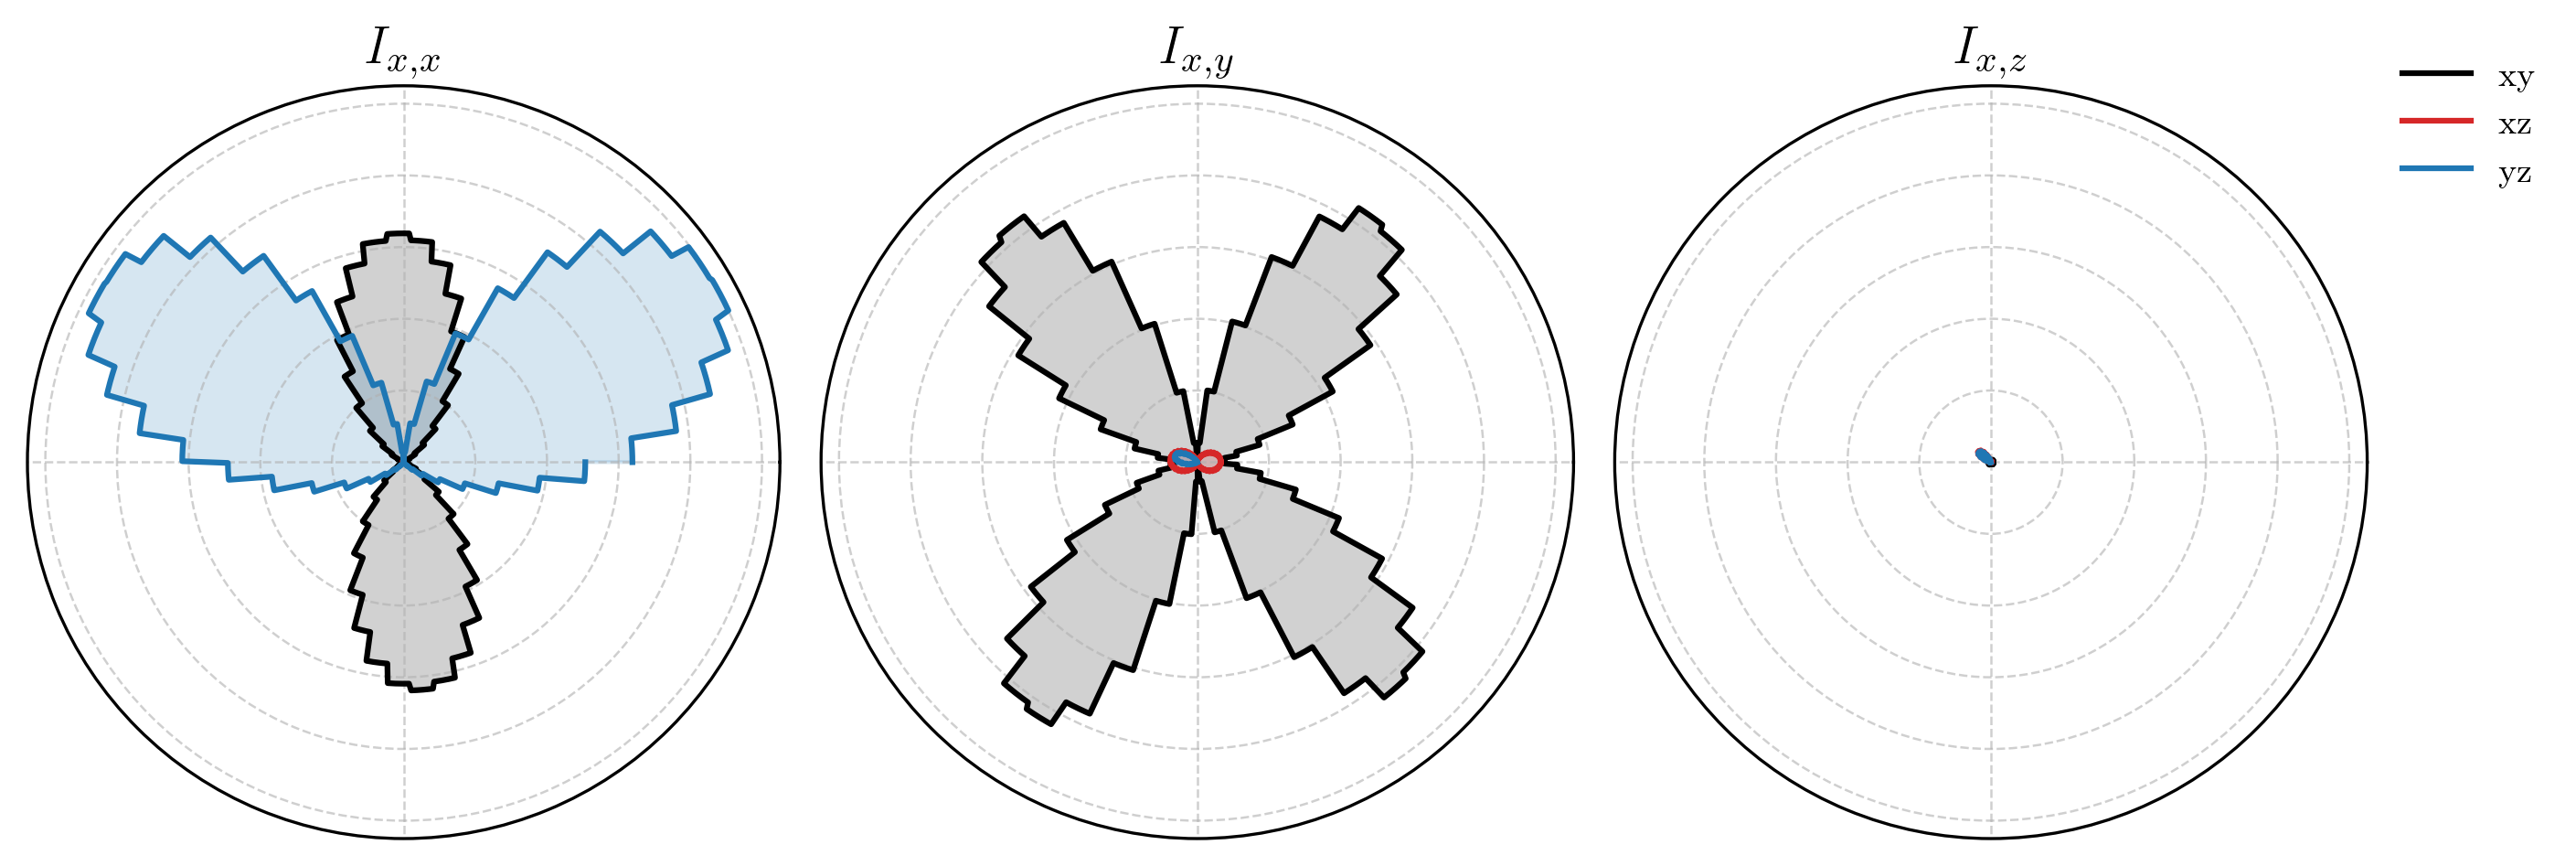

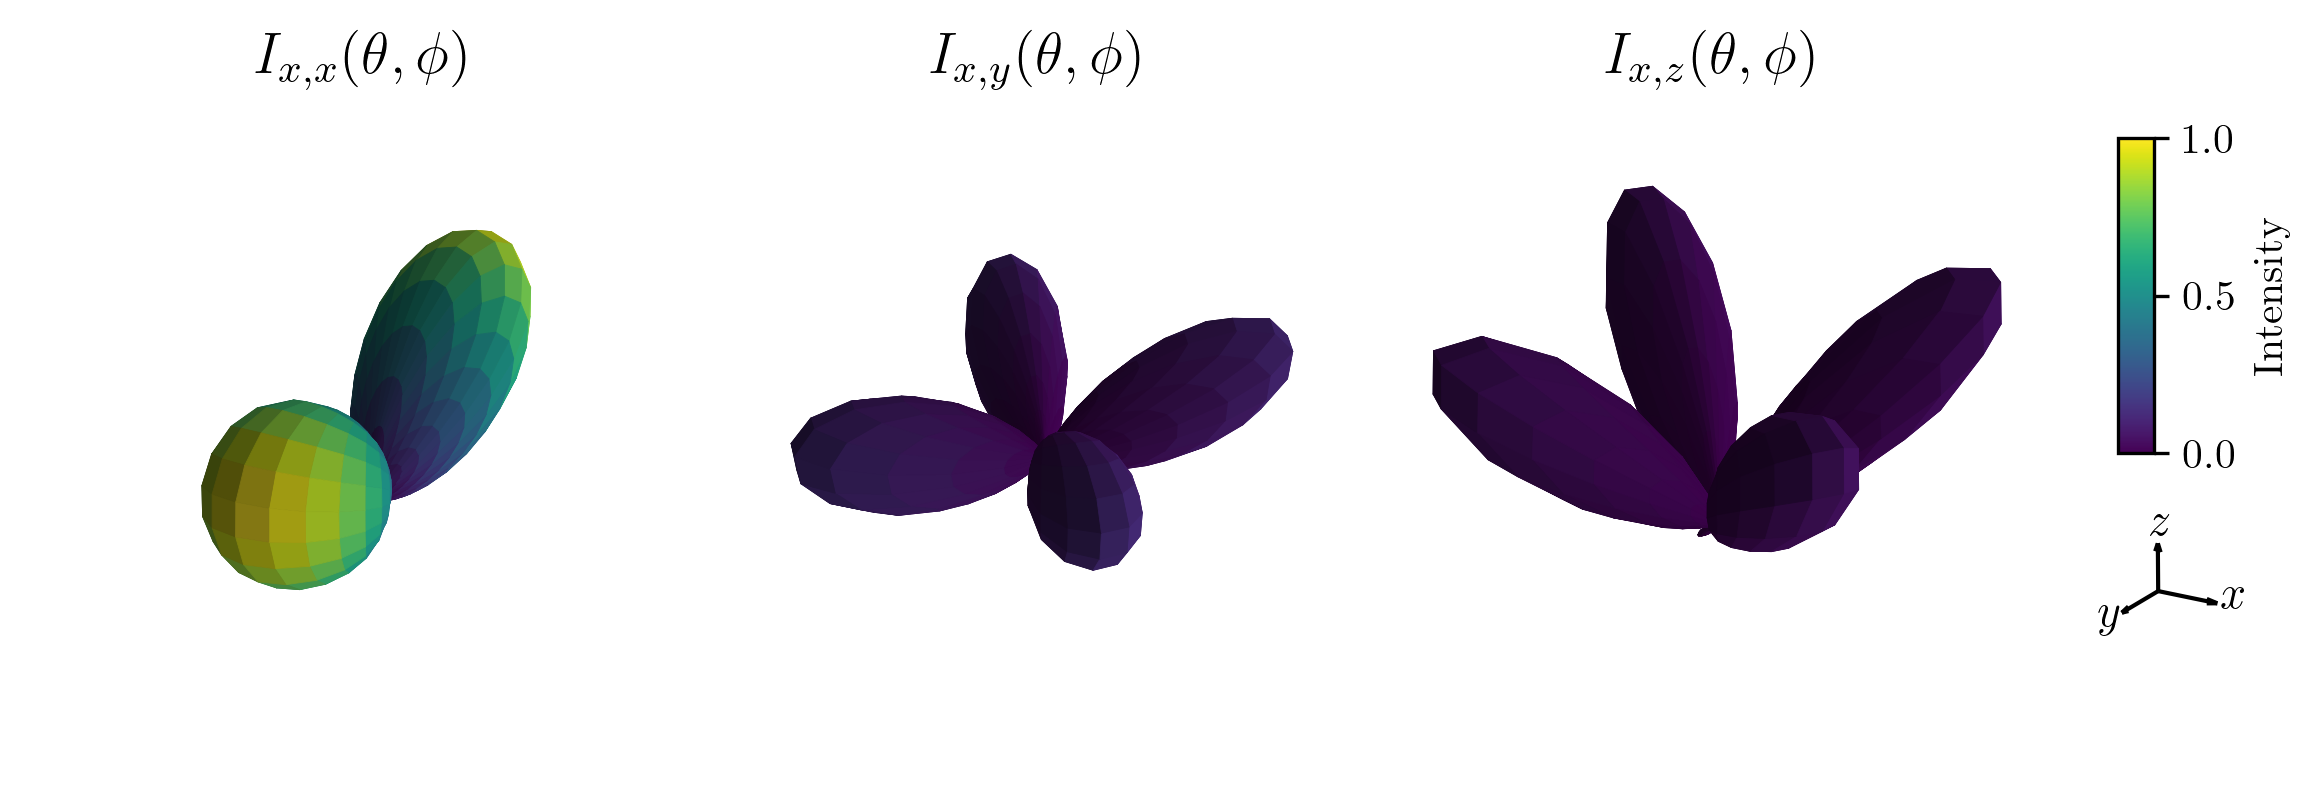

In [5]:
E_lib_plus_x, E_lib_minus_x, dE_lib_x = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_x_total, I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez = info_patterns_from_scattered_field(dE=dE_lib_x, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_Ex, I_lib_x_Ey, I_lib_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.3, 0.38, 0.38], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_x_3d", results_dir=results_dir)

## Libration around y

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 166.0ms, inv.: 933.1ms, repropa.: 4921.9ms (1 field configs), tot: 6021.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 99.5ms, inv.: 924.4ms, repropa.: 4848.0ms (1 field configs), tot: 5872.0ms


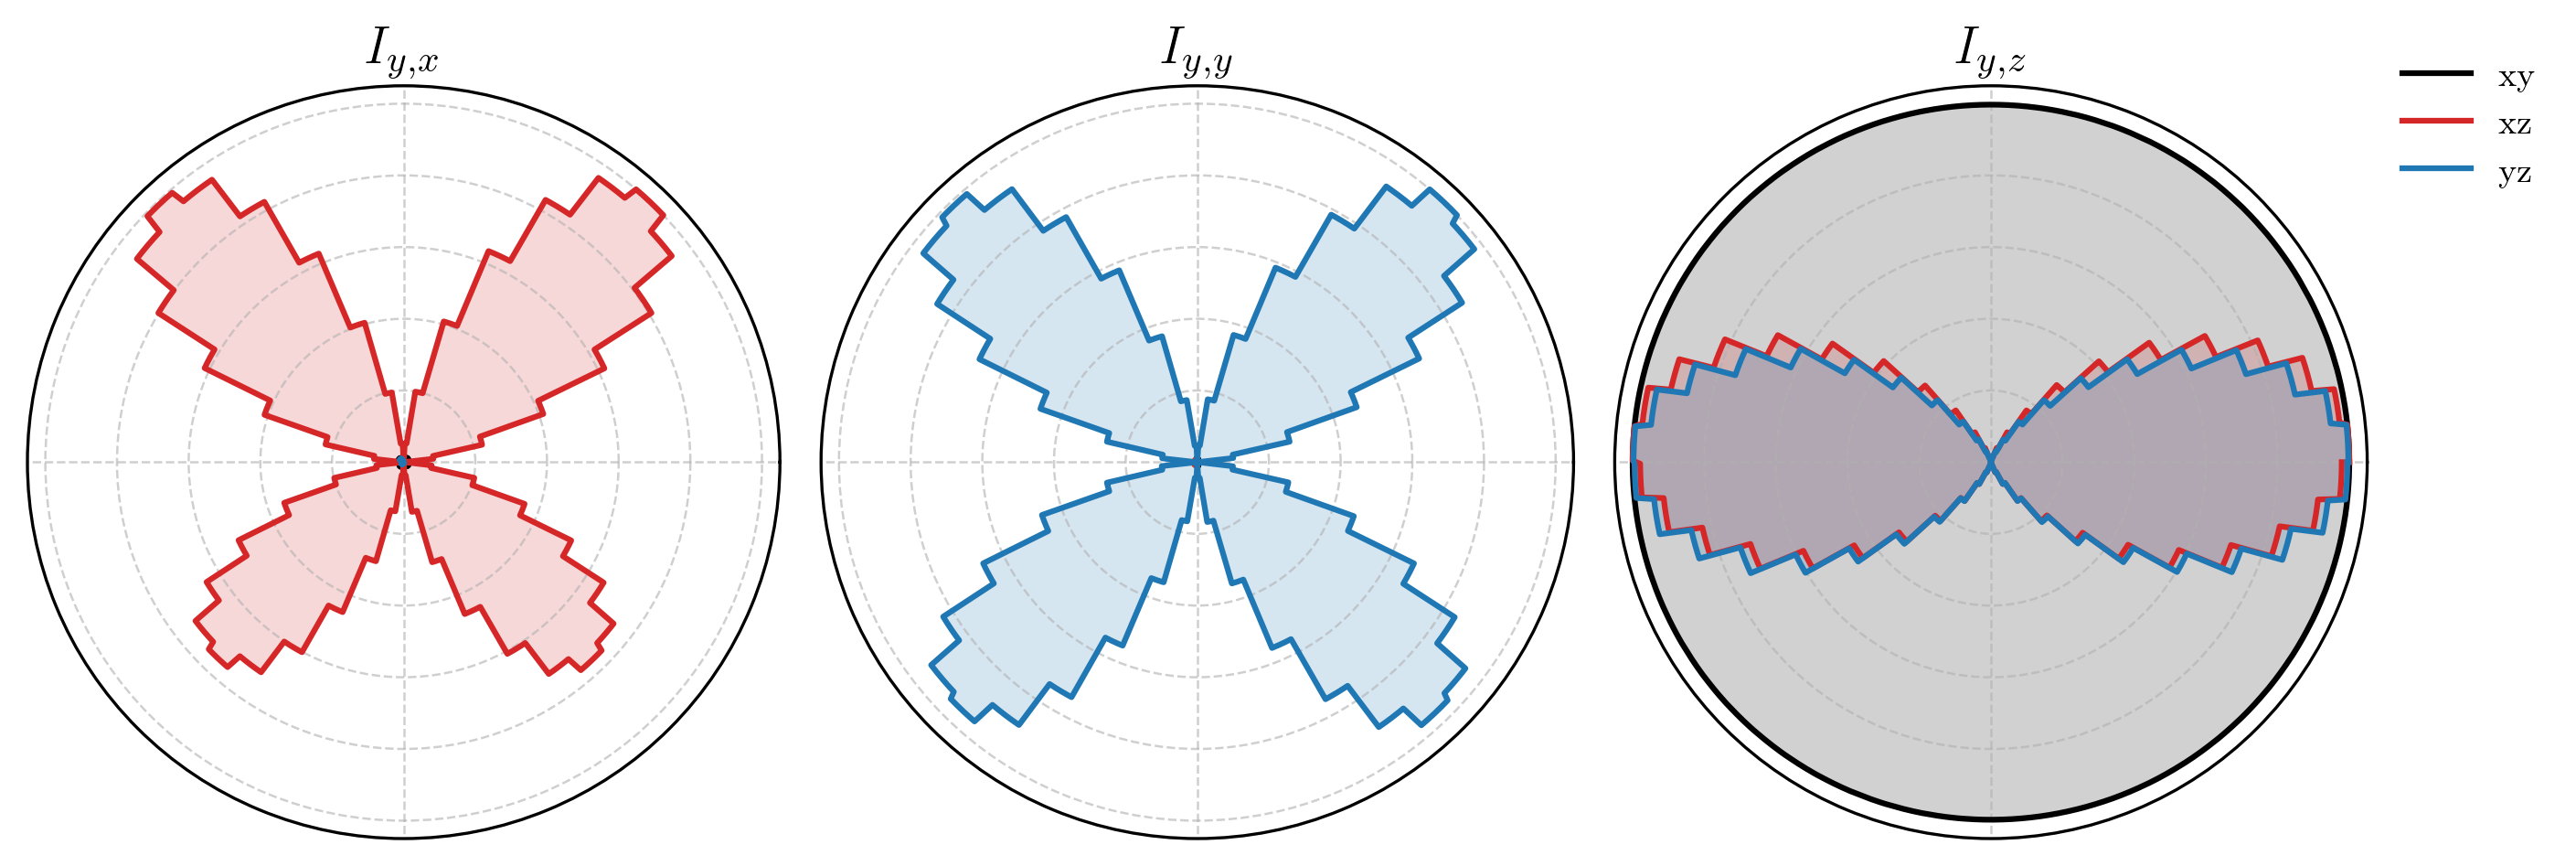

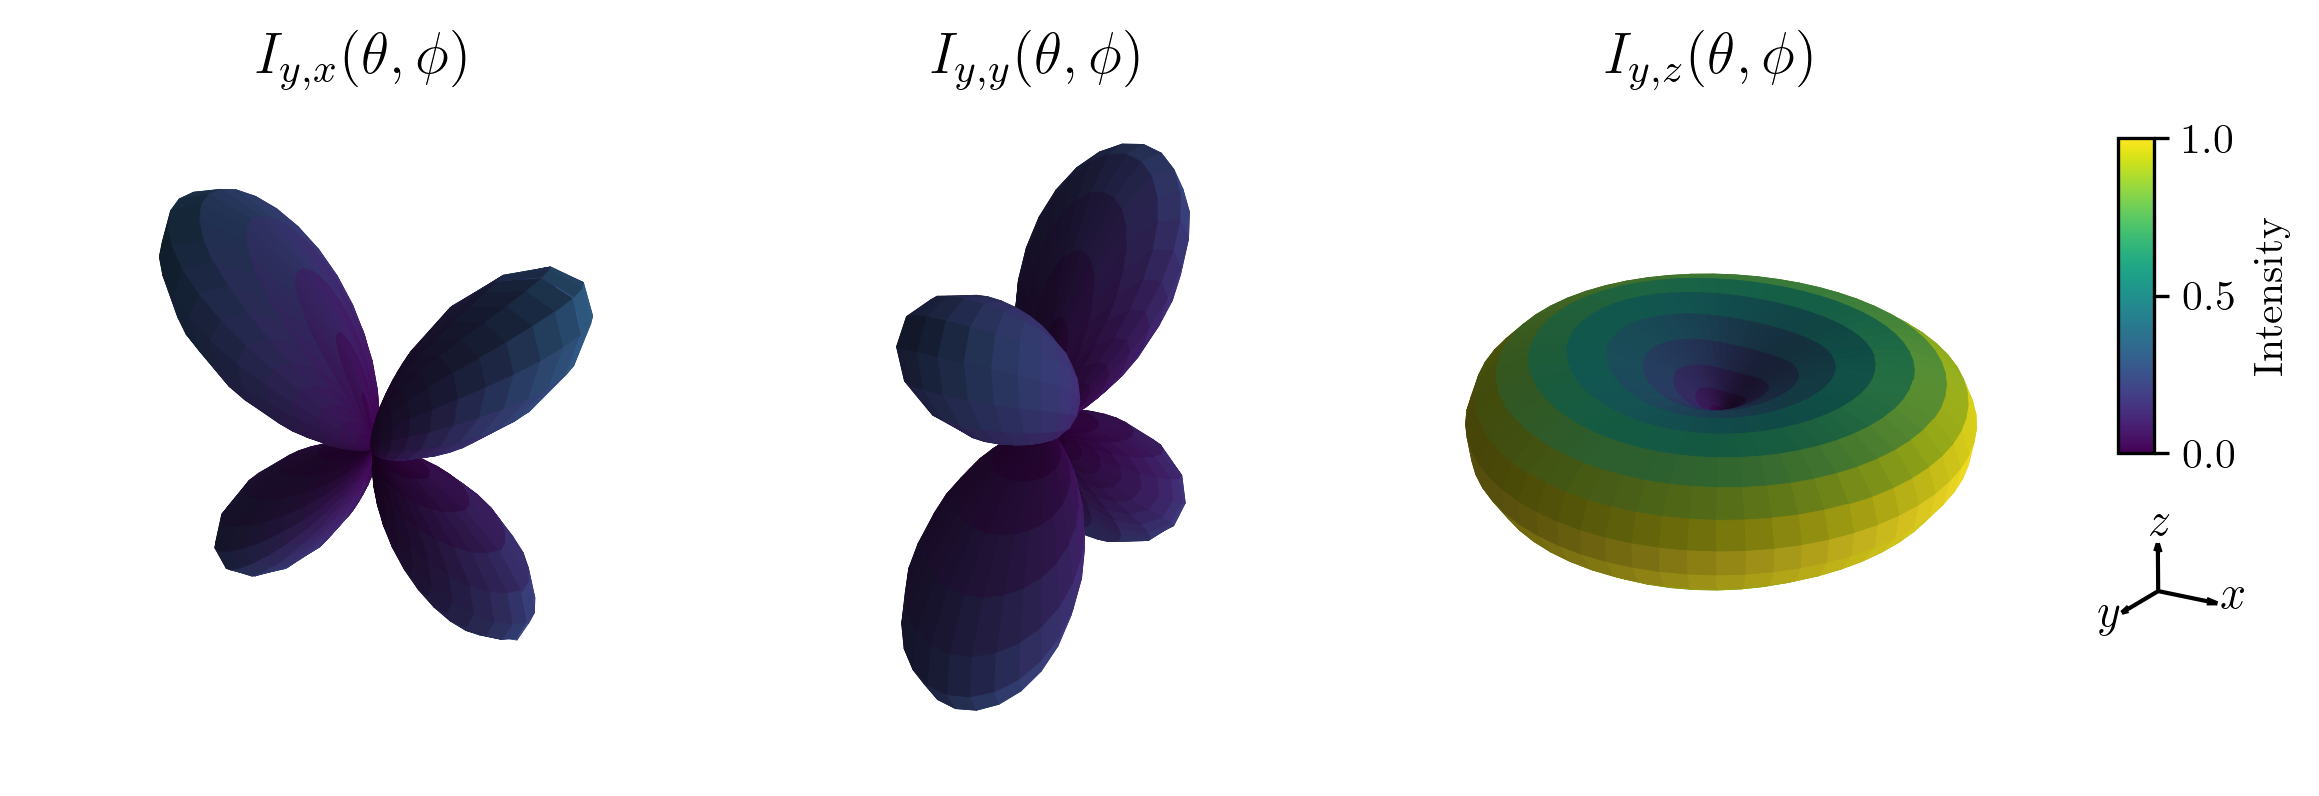

In [6]:
E_lib_plus_y, E_lib_minus_y, dE_lib_y = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_y_total, I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez = info_patterns_from_scattered_field(dE=dE_lib_y, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_y_Ex, I_lib_y_Ey, I_lib_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.38, 0.38, 0.34], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_y_3d", results_dir=results_dir)

## Libration around z

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 144.3ms, inv.: 1001.1ms, repropa.: 5186.3ms (1 field configs), tot: 6331.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 91.5ms, inv.: 1111.3ms, repropa.: 5083.4ms (1 field configs), tot: 6286.4ms


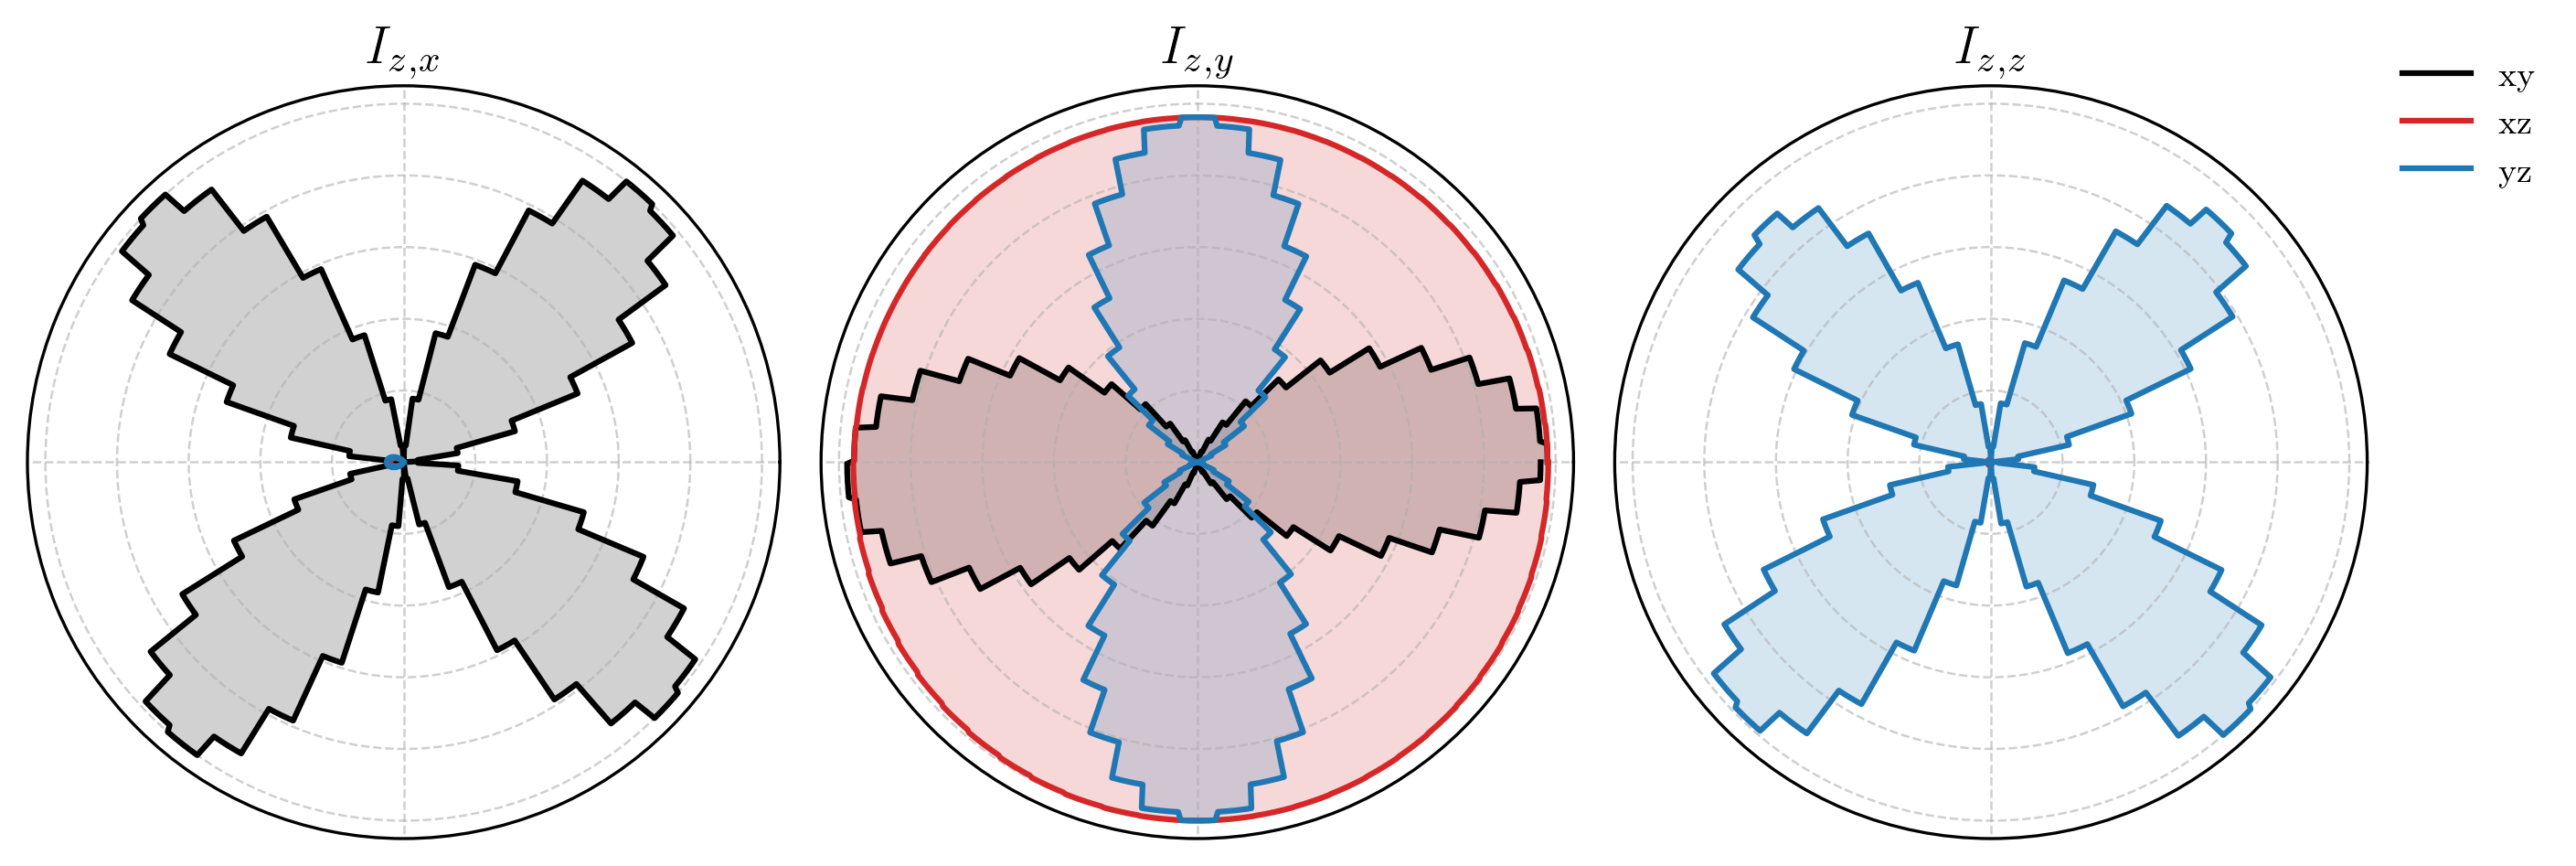

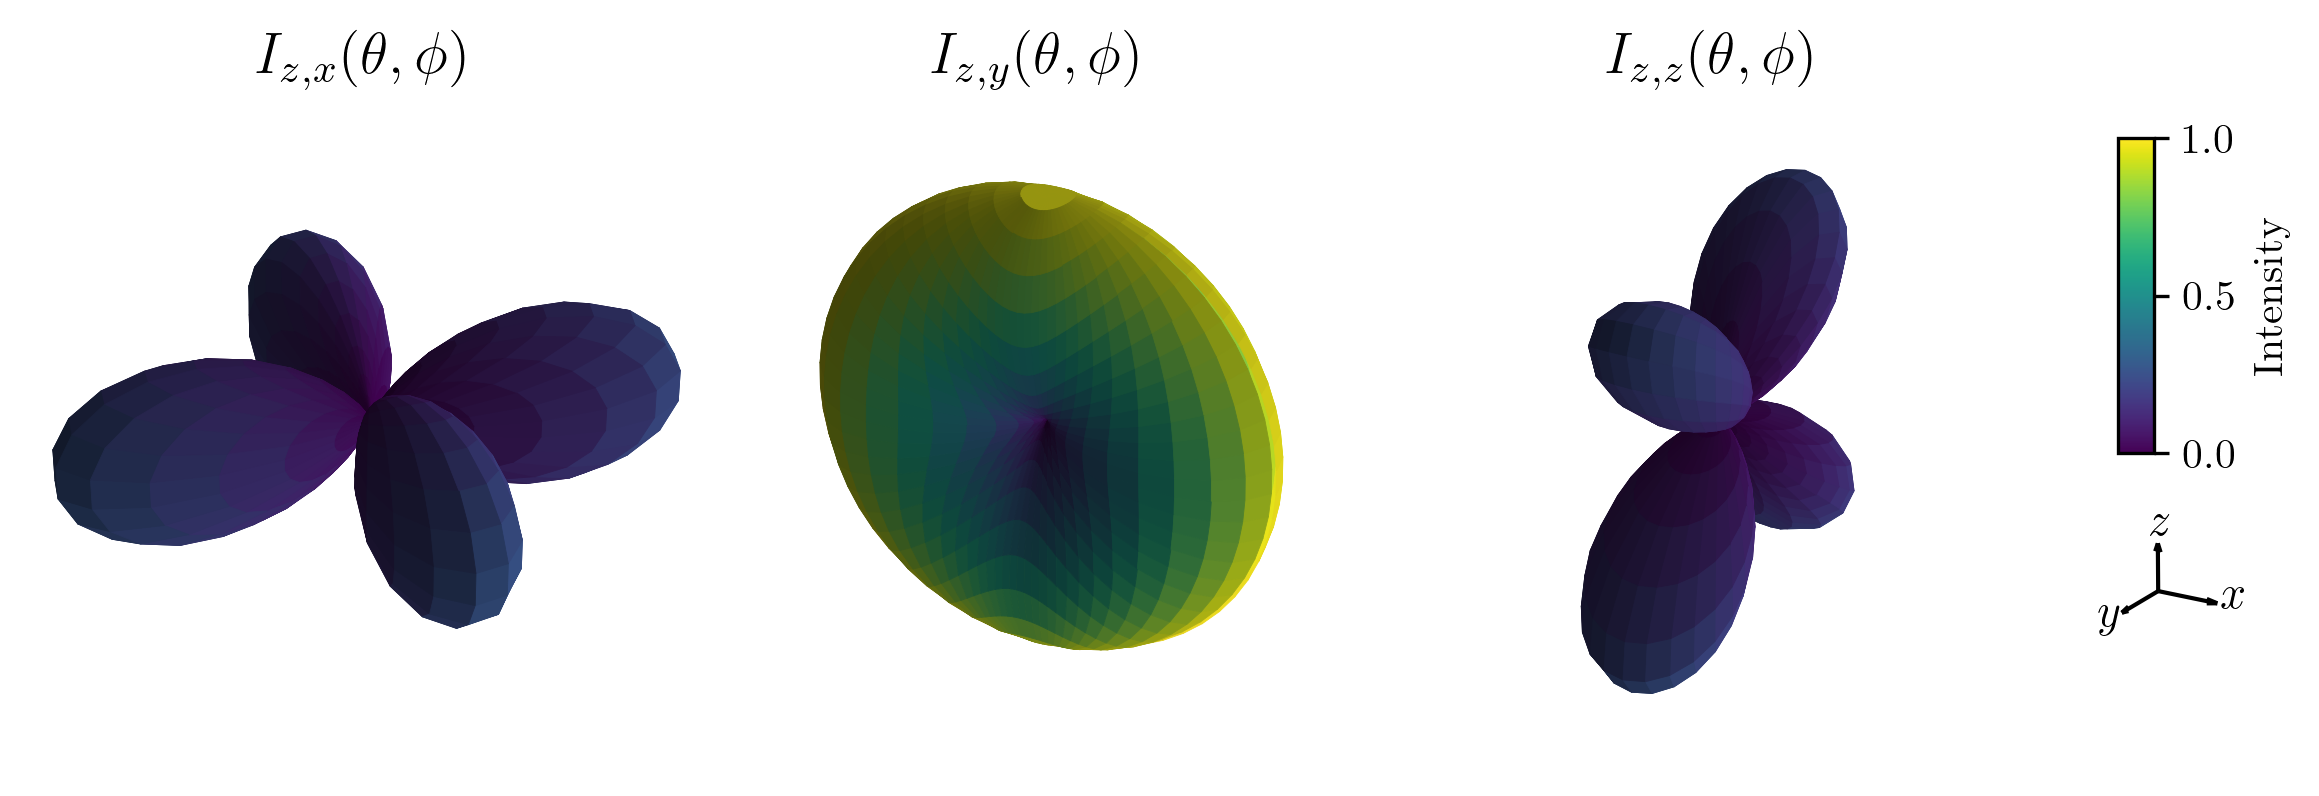

In [7]:
E_lib_plus_z, E_lib_minus_z, dE_lib_z = librational_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, angle_deg=angle_deg, 
                                                                       Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_lib_z_total, I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez = info_patterns_from_scattered_field(dE=dE_lib_z, delta_mu=angle_deg, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_z_Ex, I_lib_z_Ey, I_lib_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.34, 0.34, 0.4], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_z_3d", results_dir=results_dir)

## Total librational information patterns

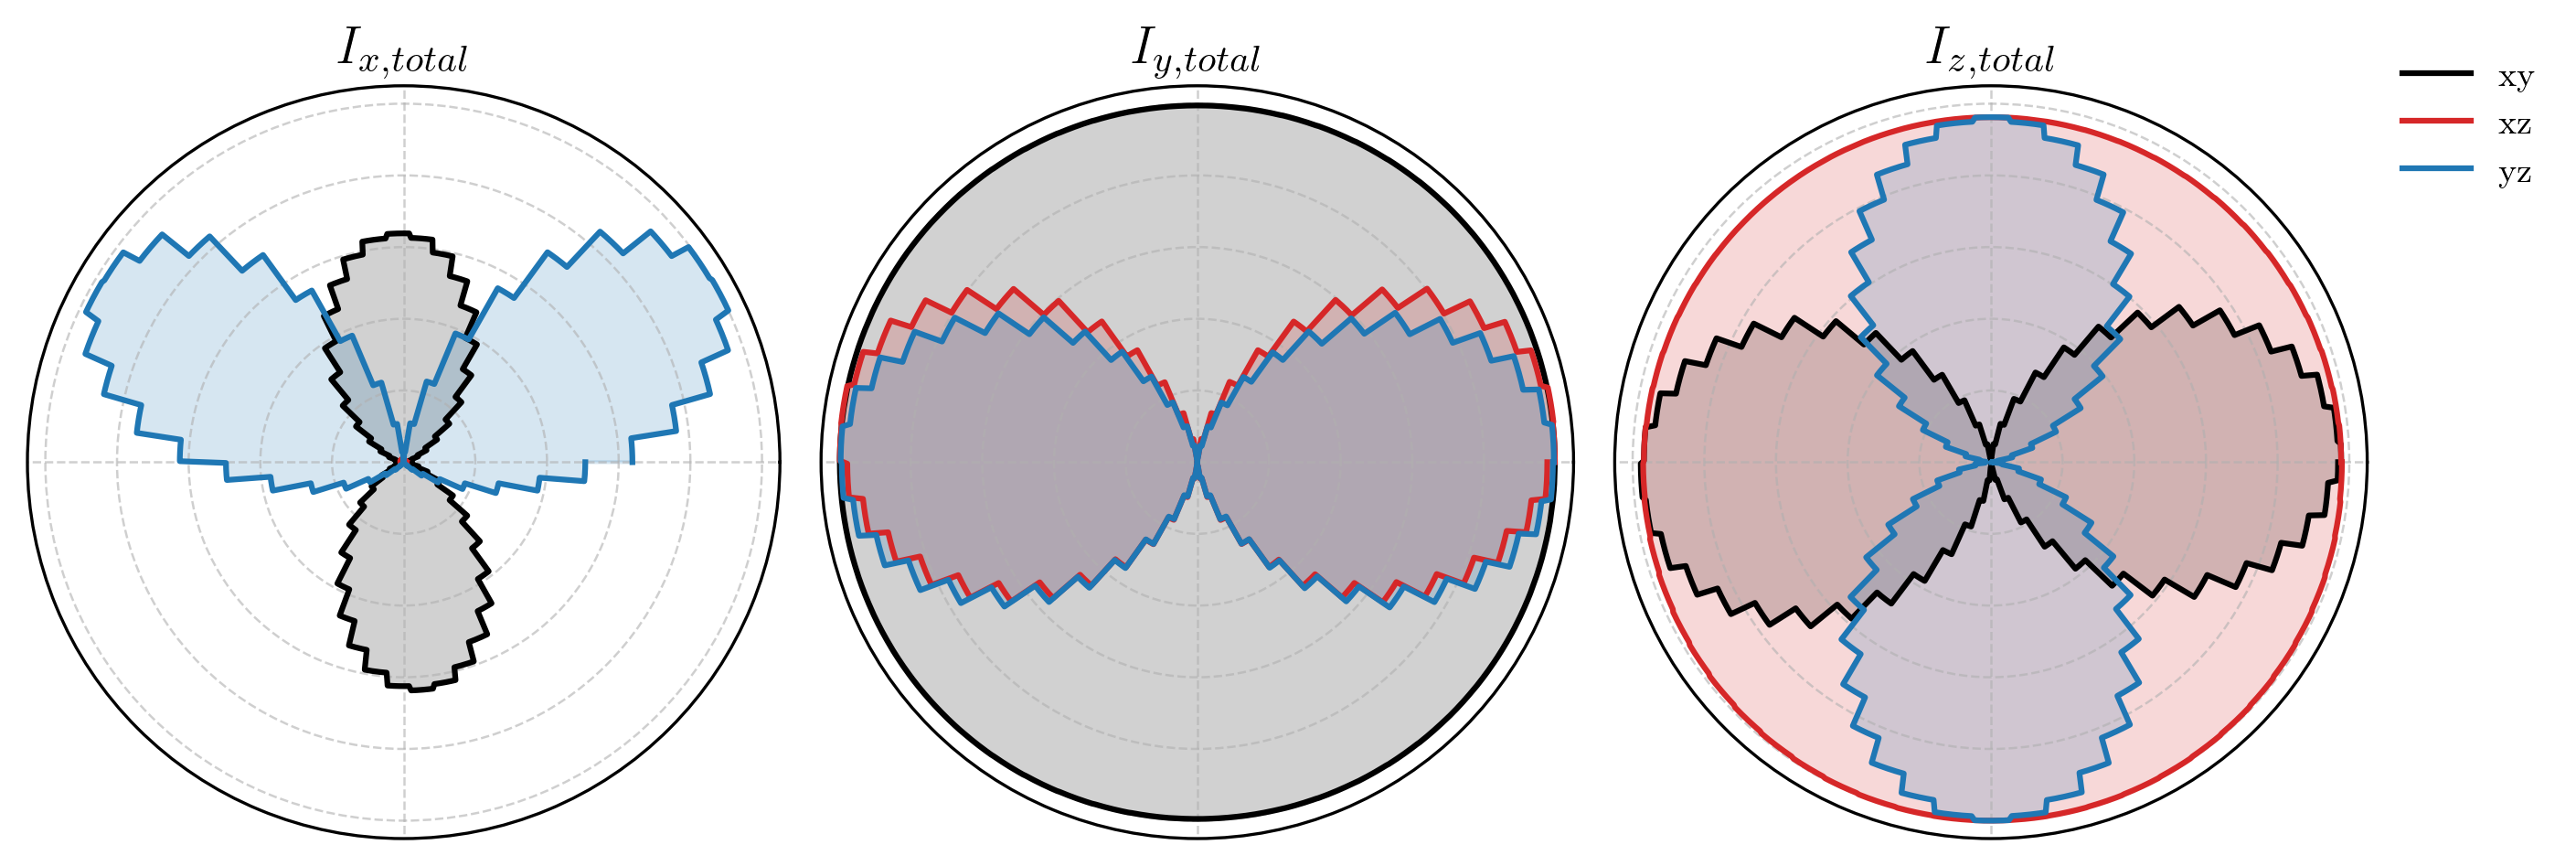

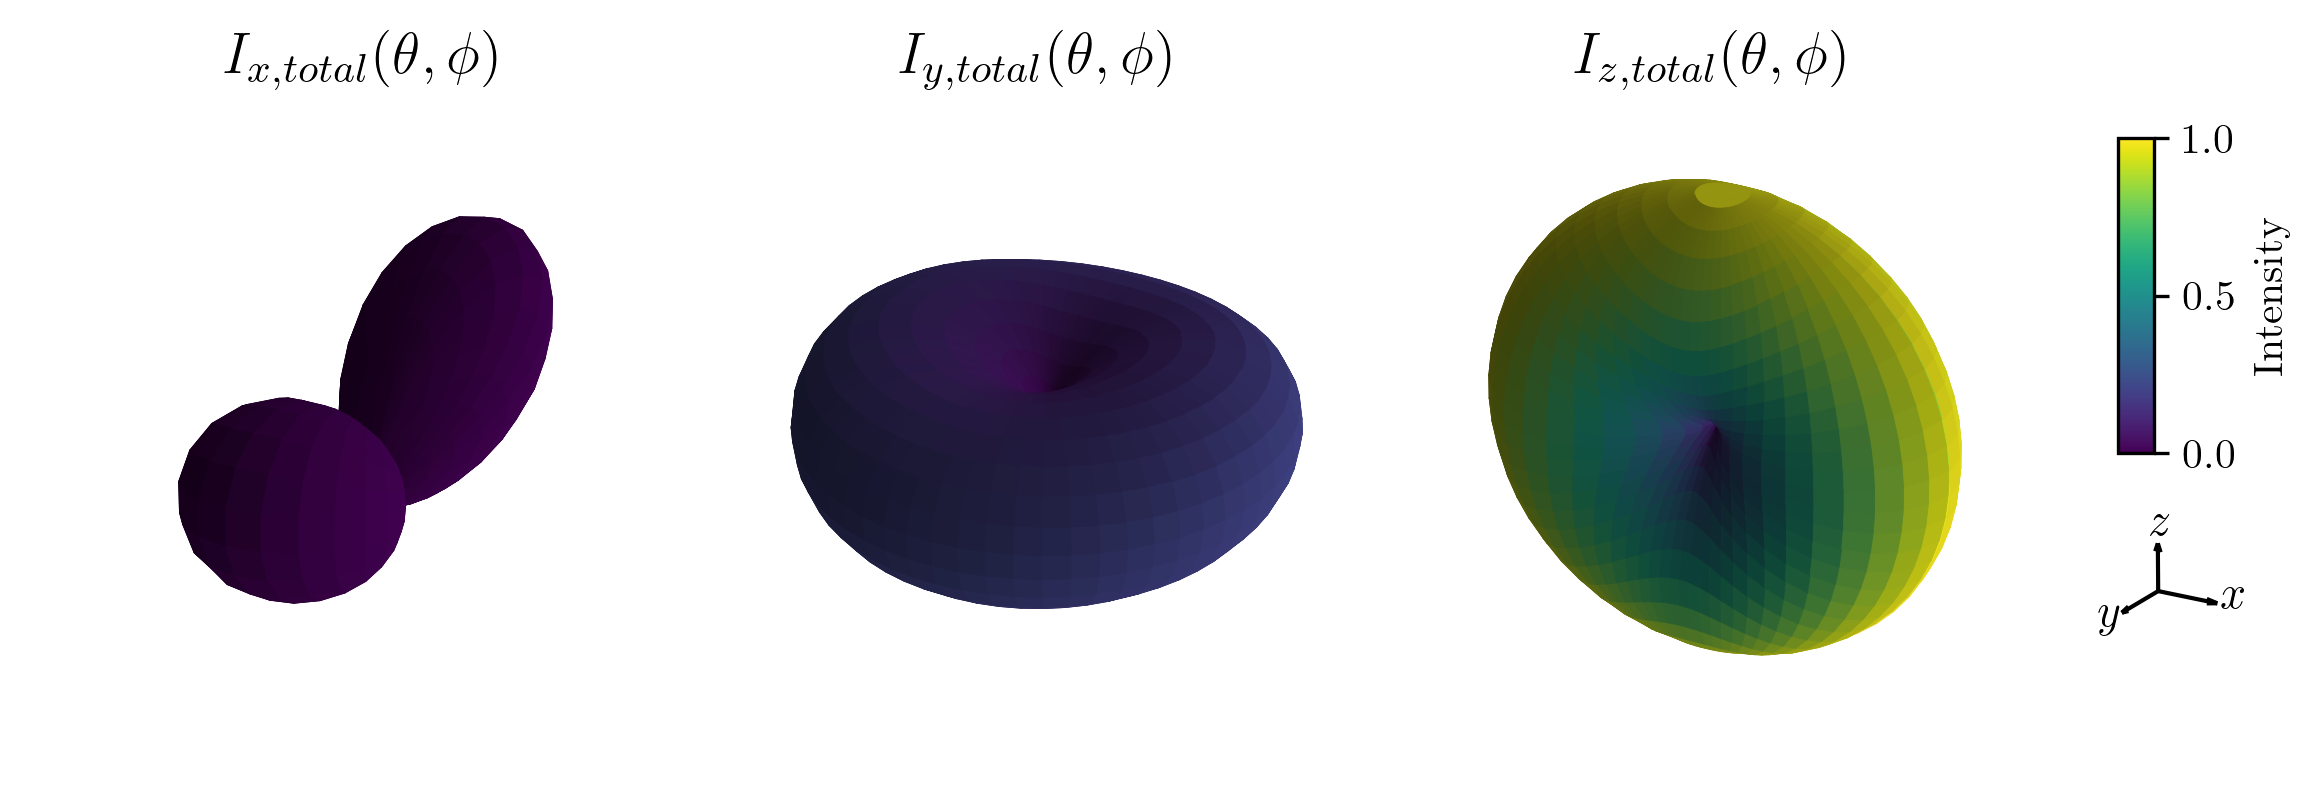

In [8]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_lib_x_total, I_lib_y_total, I_lib_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, scale_list=[0.28, 0.34, 0.34], 
                     savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="lib_info_patterns_total_3d", results_dir=results_dir)

## COM displacement along x

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 278.0ms, inv.: 1054.9ms, repropa.: 4953.1ms (1 field configs), tot: 6286.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 120.5ms, inv.: 1061.6ms, repropa.: 4703.3ms (1 field configs), tot: 5885.5ms


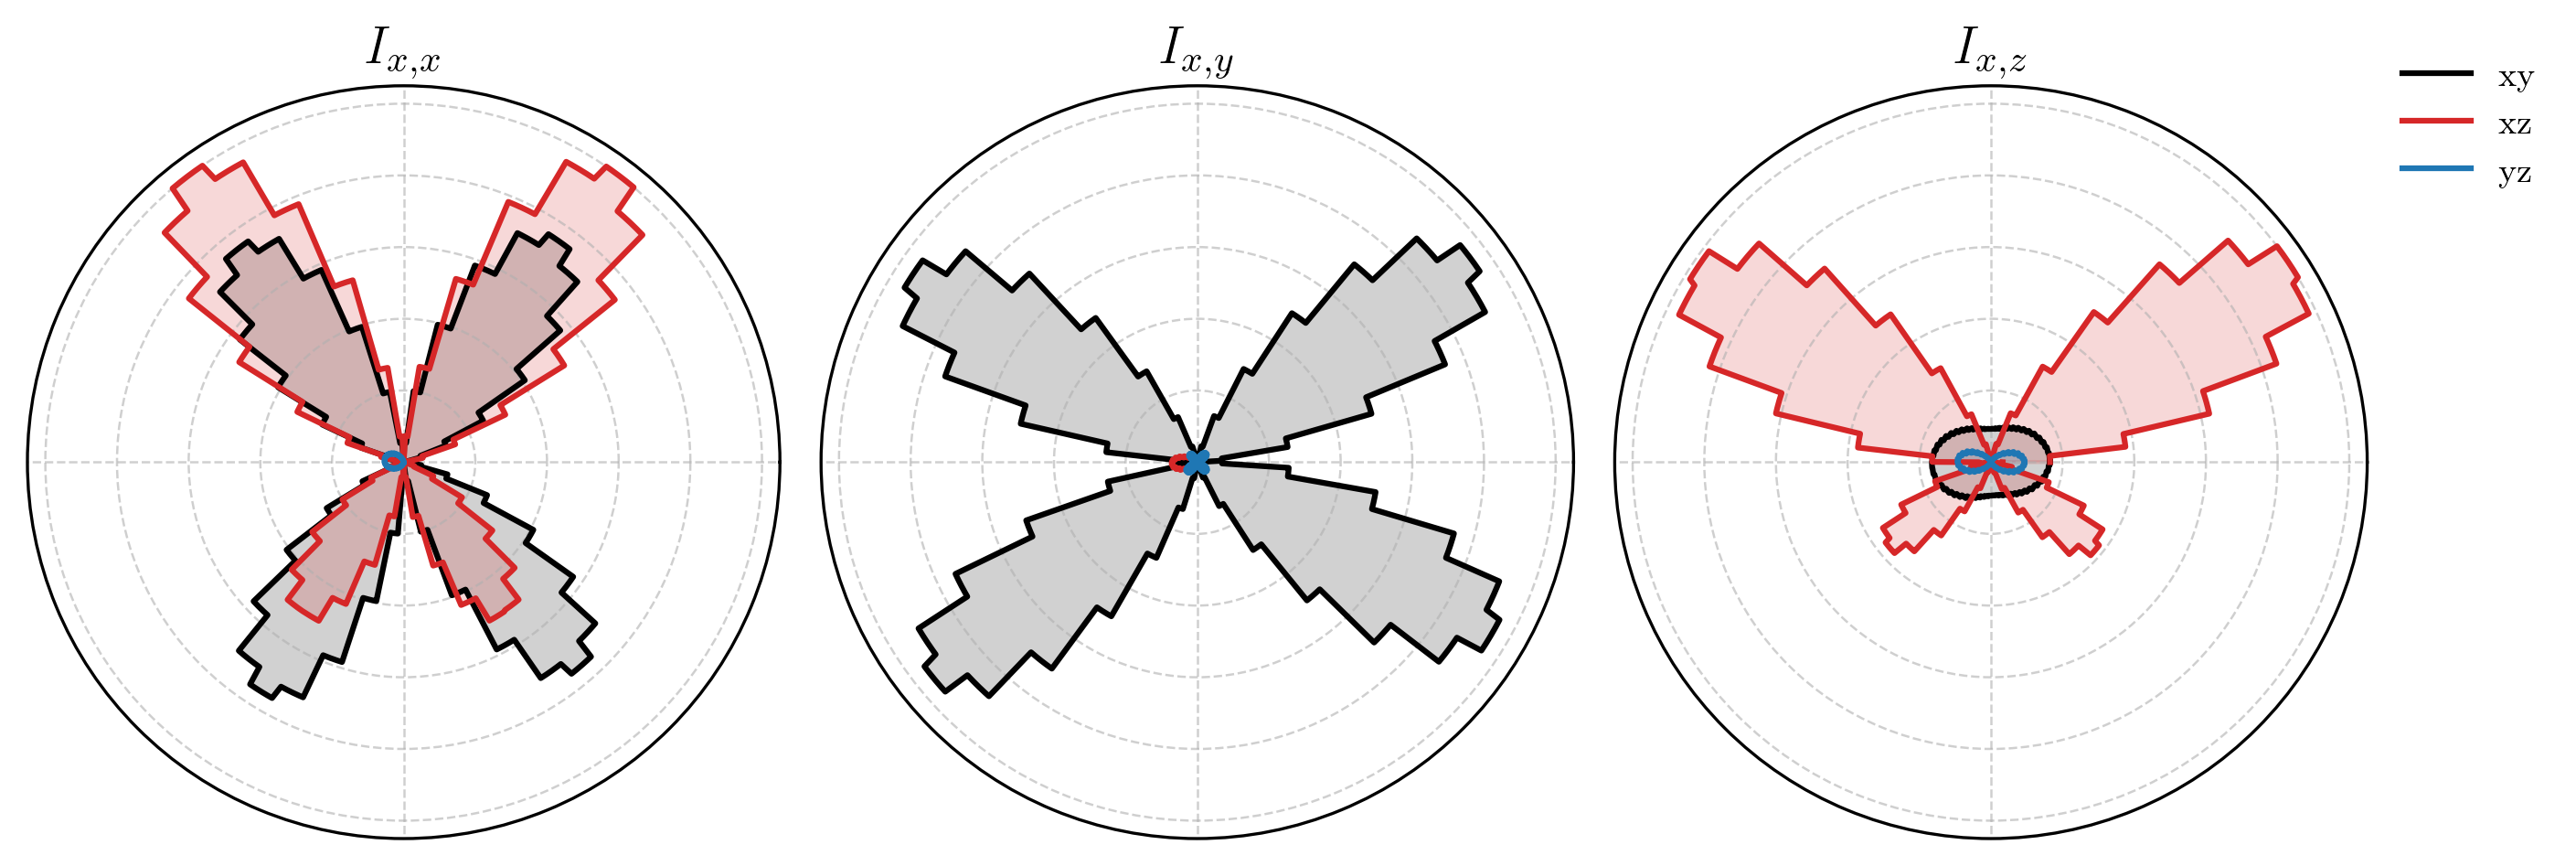

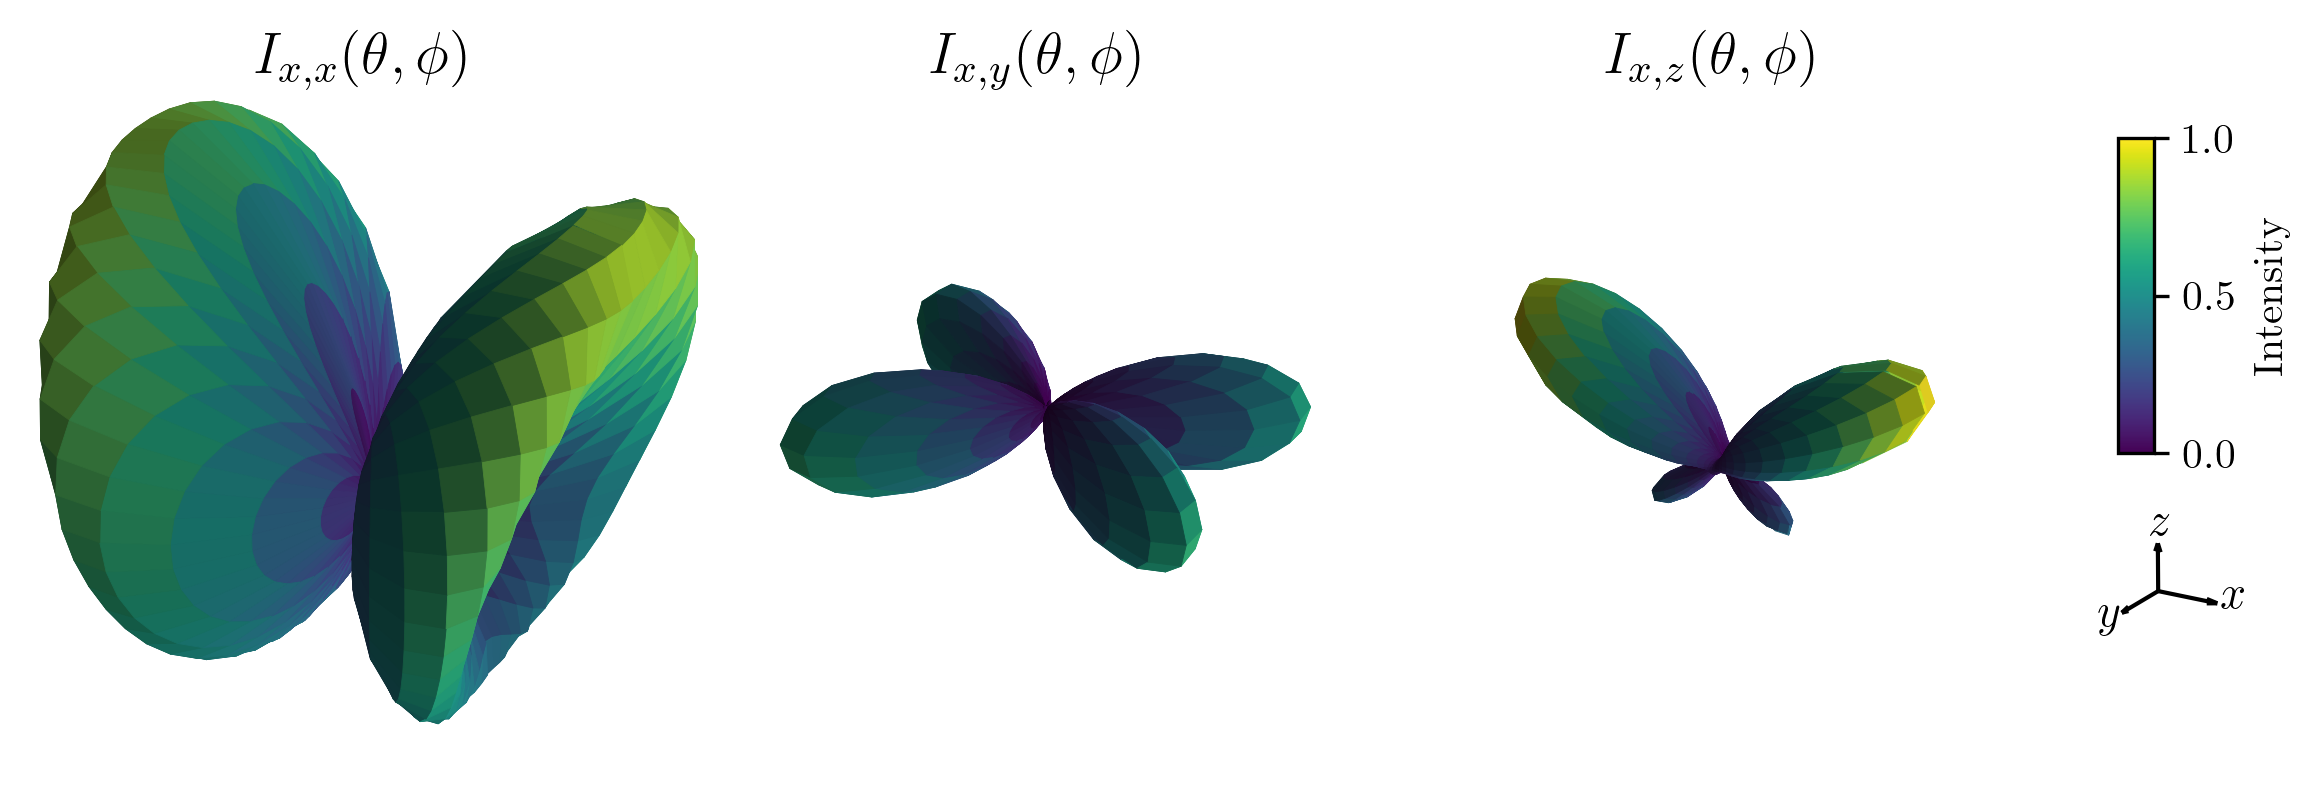

In [9]:
E_com_plus_x, E_com_minus_x, dE_com_x = com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=0, disp_nm=disp_nm, 
                                                               Nteta=Nteta, Nphi=Nphi, field_index=field_index, r=r)
I_com_x_total, I_com_x_Ex, I_com_x_Ey, I_com_x_Ez = info_patterns_from_scattered_field(dE=dE_com_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_Ex, I_com_x_Ey, I_com_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_x_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_Ex, I_com_x_Ey, I_com_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, scale_list=[0.3, 0.38, 0.38], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_x_3d", results_dir=results_dir)

## COM displacement along y

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 124.7ms, inv.: 940.7ms, repropa.: 4073.1ms (1 field configs), tot: 5138.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 94.5ms, inv.: 1036.4ms, repropa.: 4828.1ms (1 field configs), tot: 5959.1ms


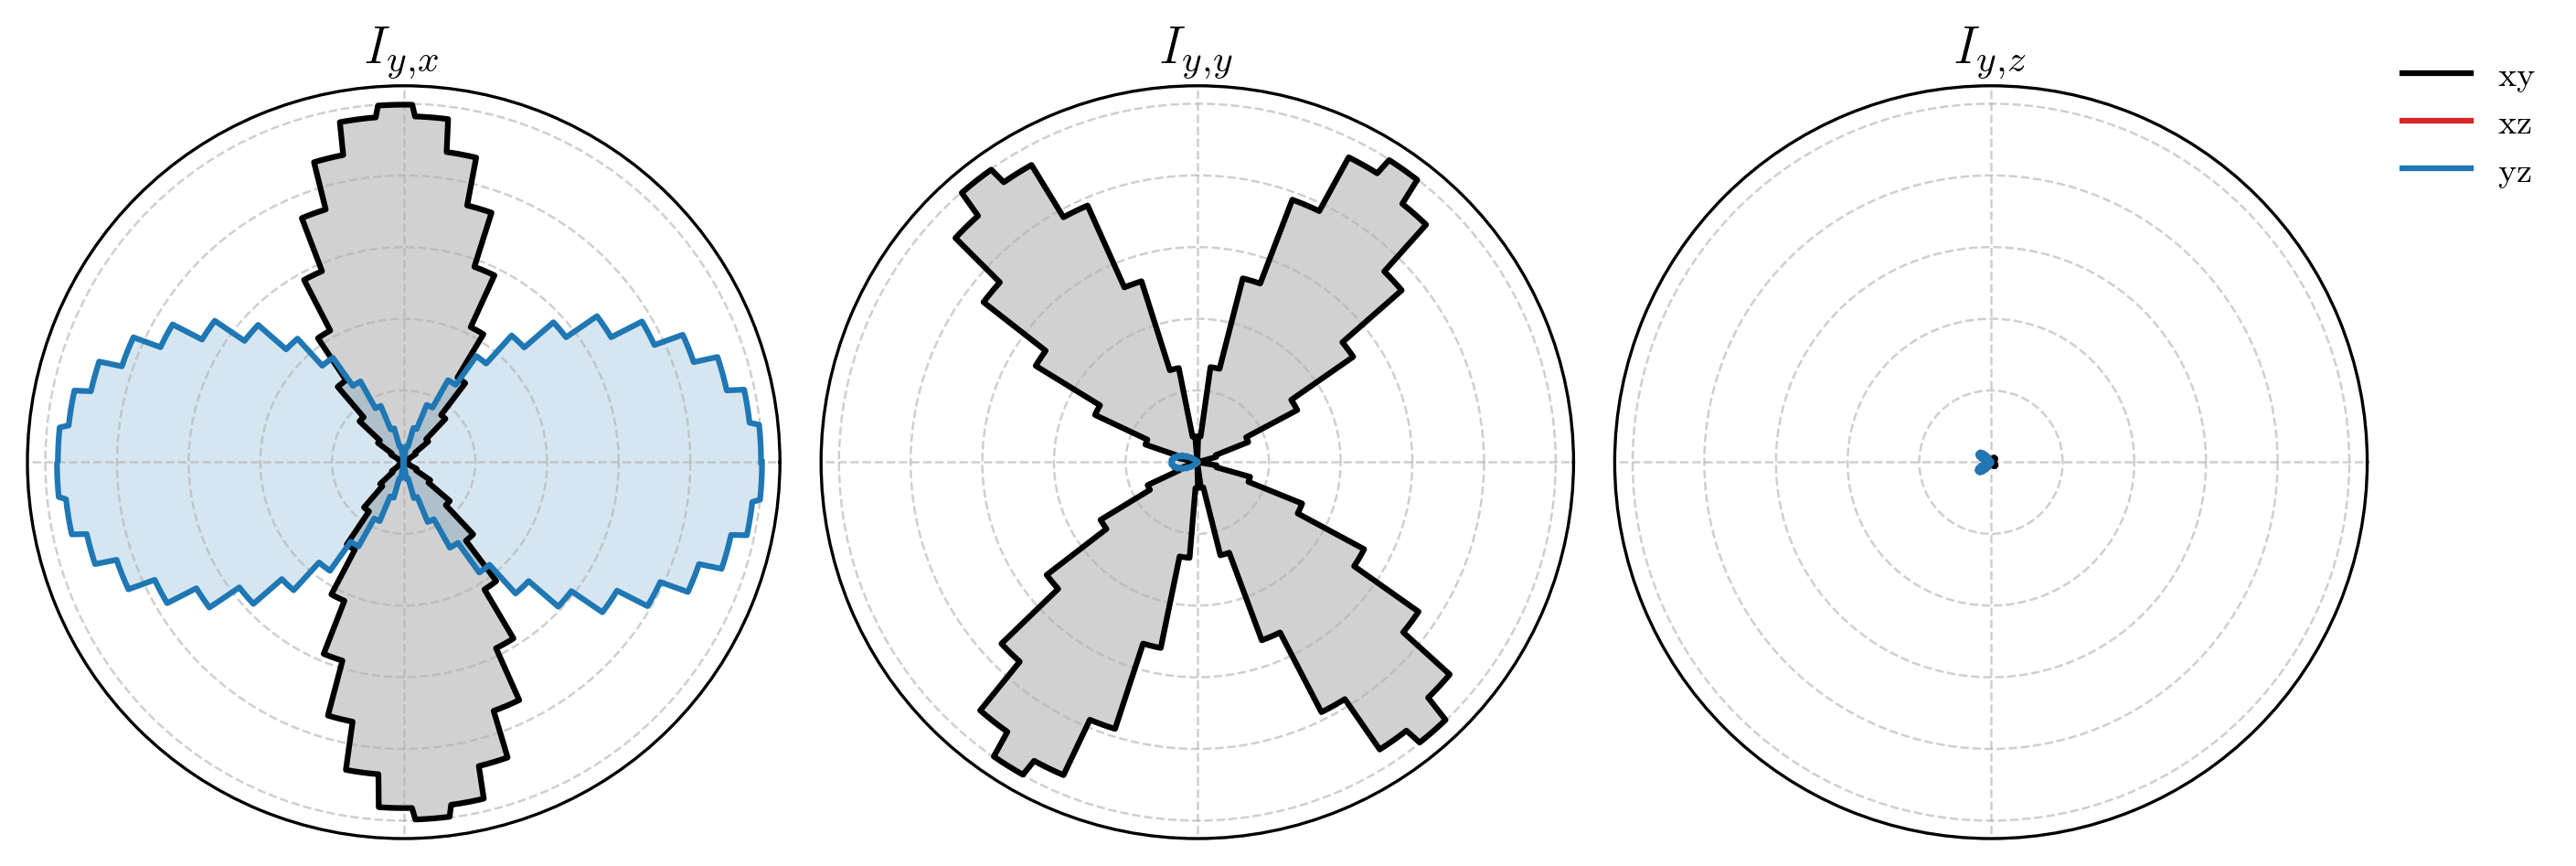

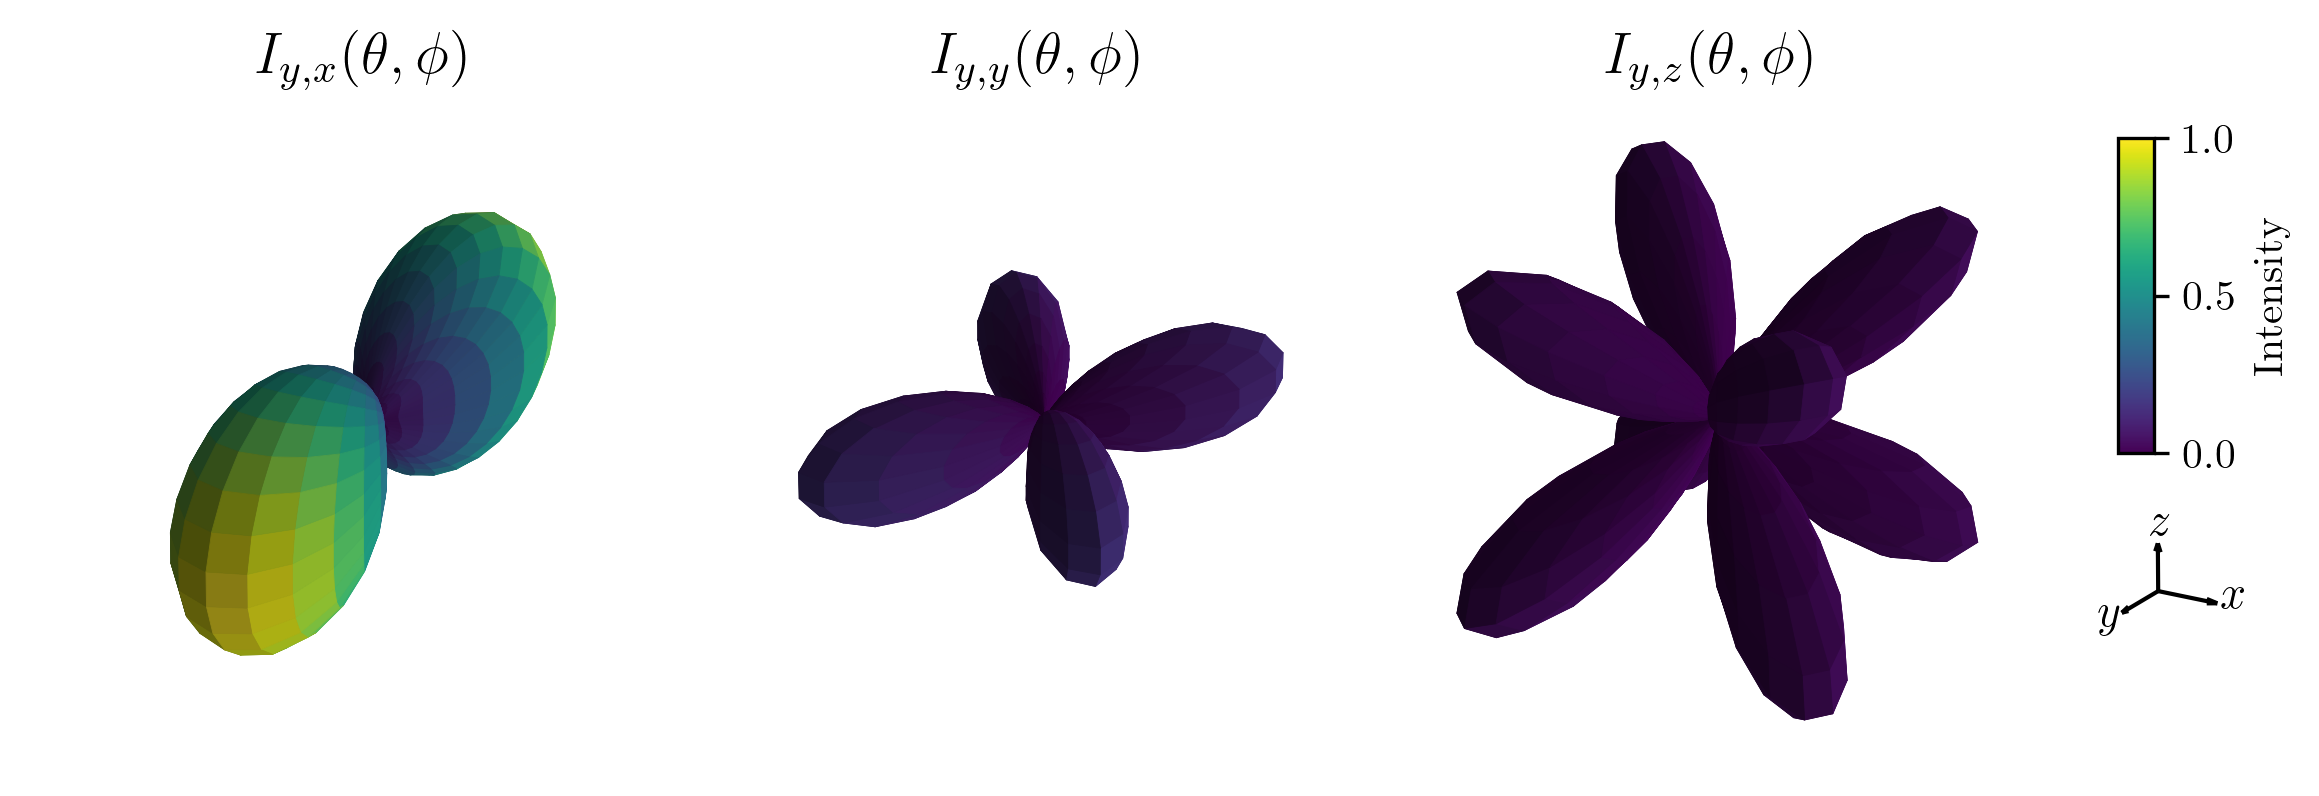

In [10]:
E_com_plus_y, E_com_minus_y, dE_com_y = com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=1, disp_nm=disp_nm, Nteta=Nteta, 
                                                               Nphi=Nphi, field_index=field_index, r=r)
I_com_y_total, I_com_y_Ex, I_com_y_Ey, I_com_y_Ez = info_patterns_from_scattered_field(dE=dE_com_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_y_Ex, I_com_y_Ey, I_com_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_y_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_y_Ex, I_com_y_Ey, I_com_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, scale_list=[0.25, 0.38, 0.40], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_y_3d", results_dir=results_dir)

## COM displacement along z

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 133.6ms, inv.: 877.4ms, repropa.: 4992.1ms (1 field configs), tot: 6003.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 137.3ms, inv.: 947.0ms, repropa.: 5102.5ms (1 field configs), tot: 6186.8ms


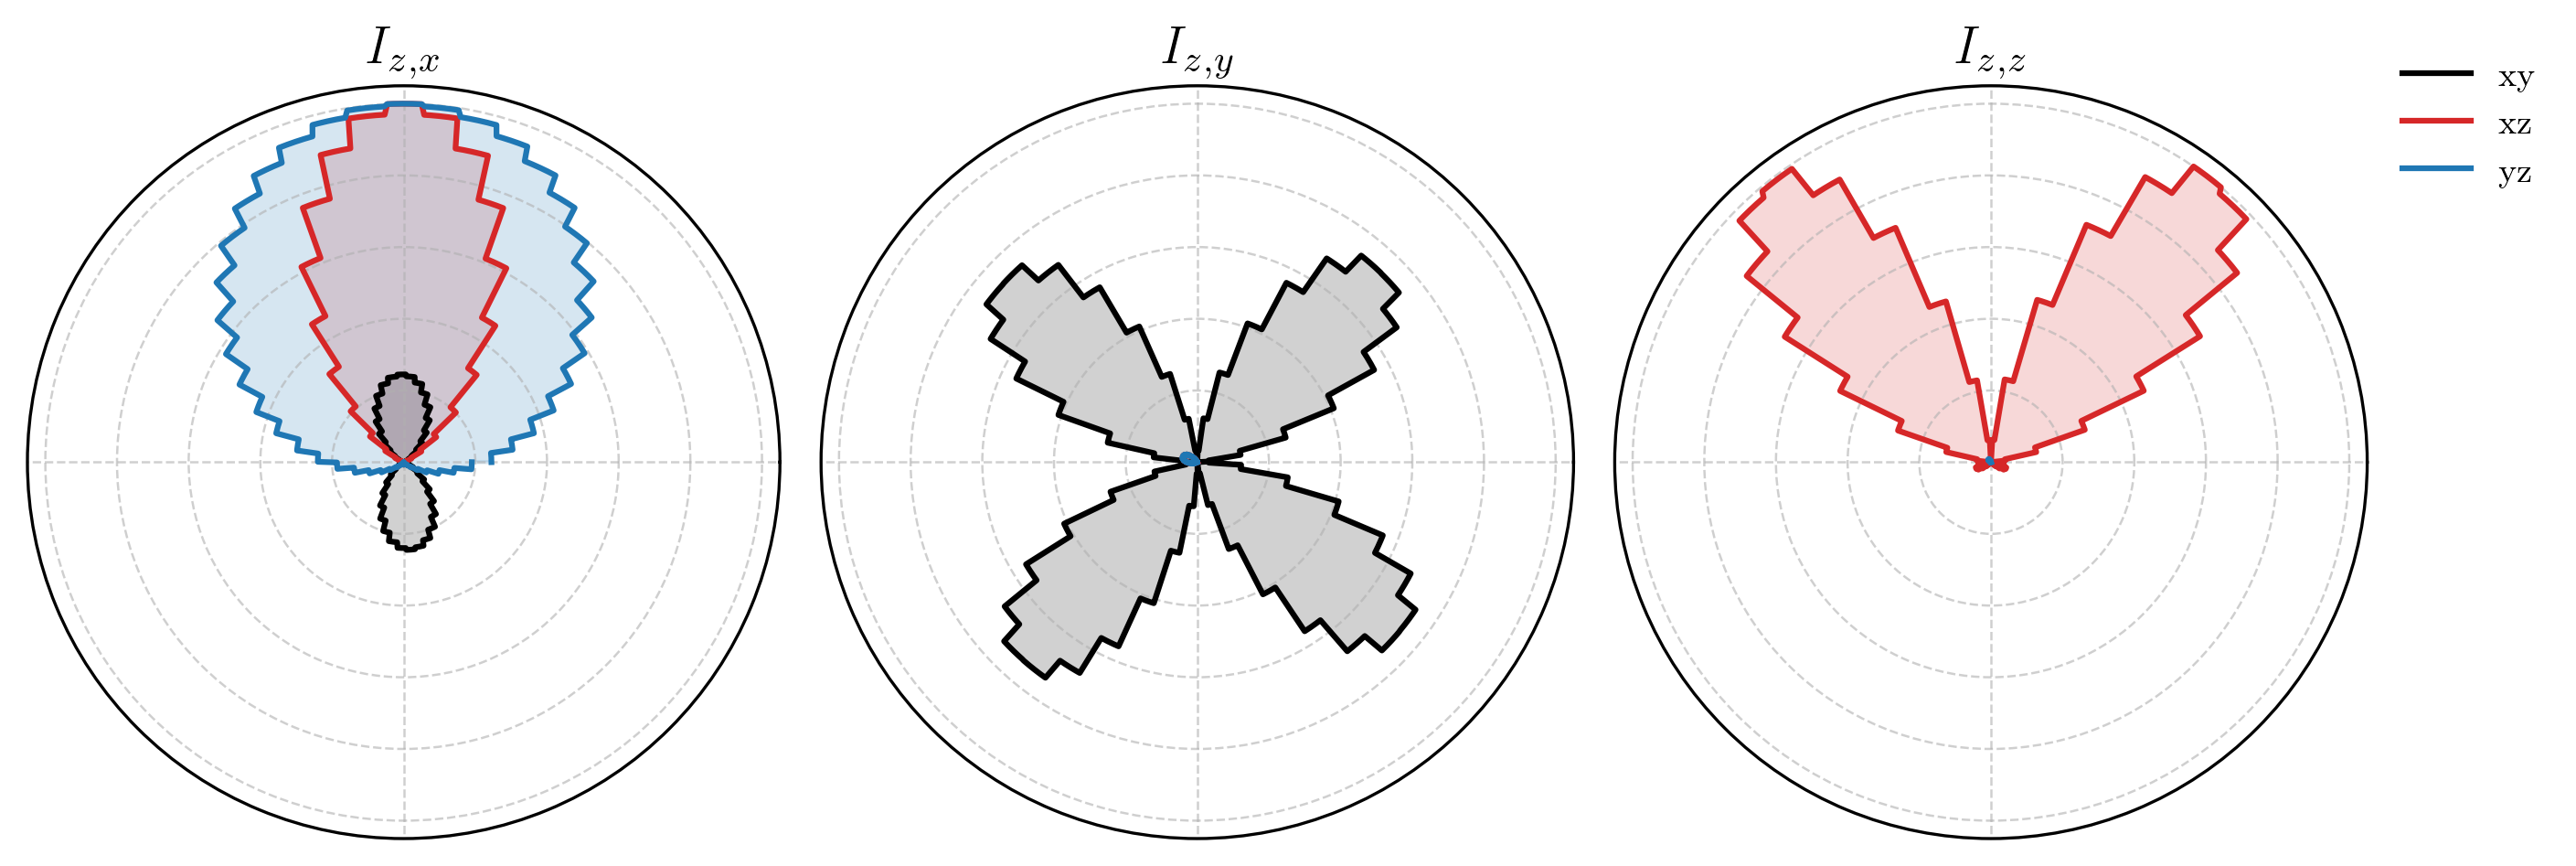

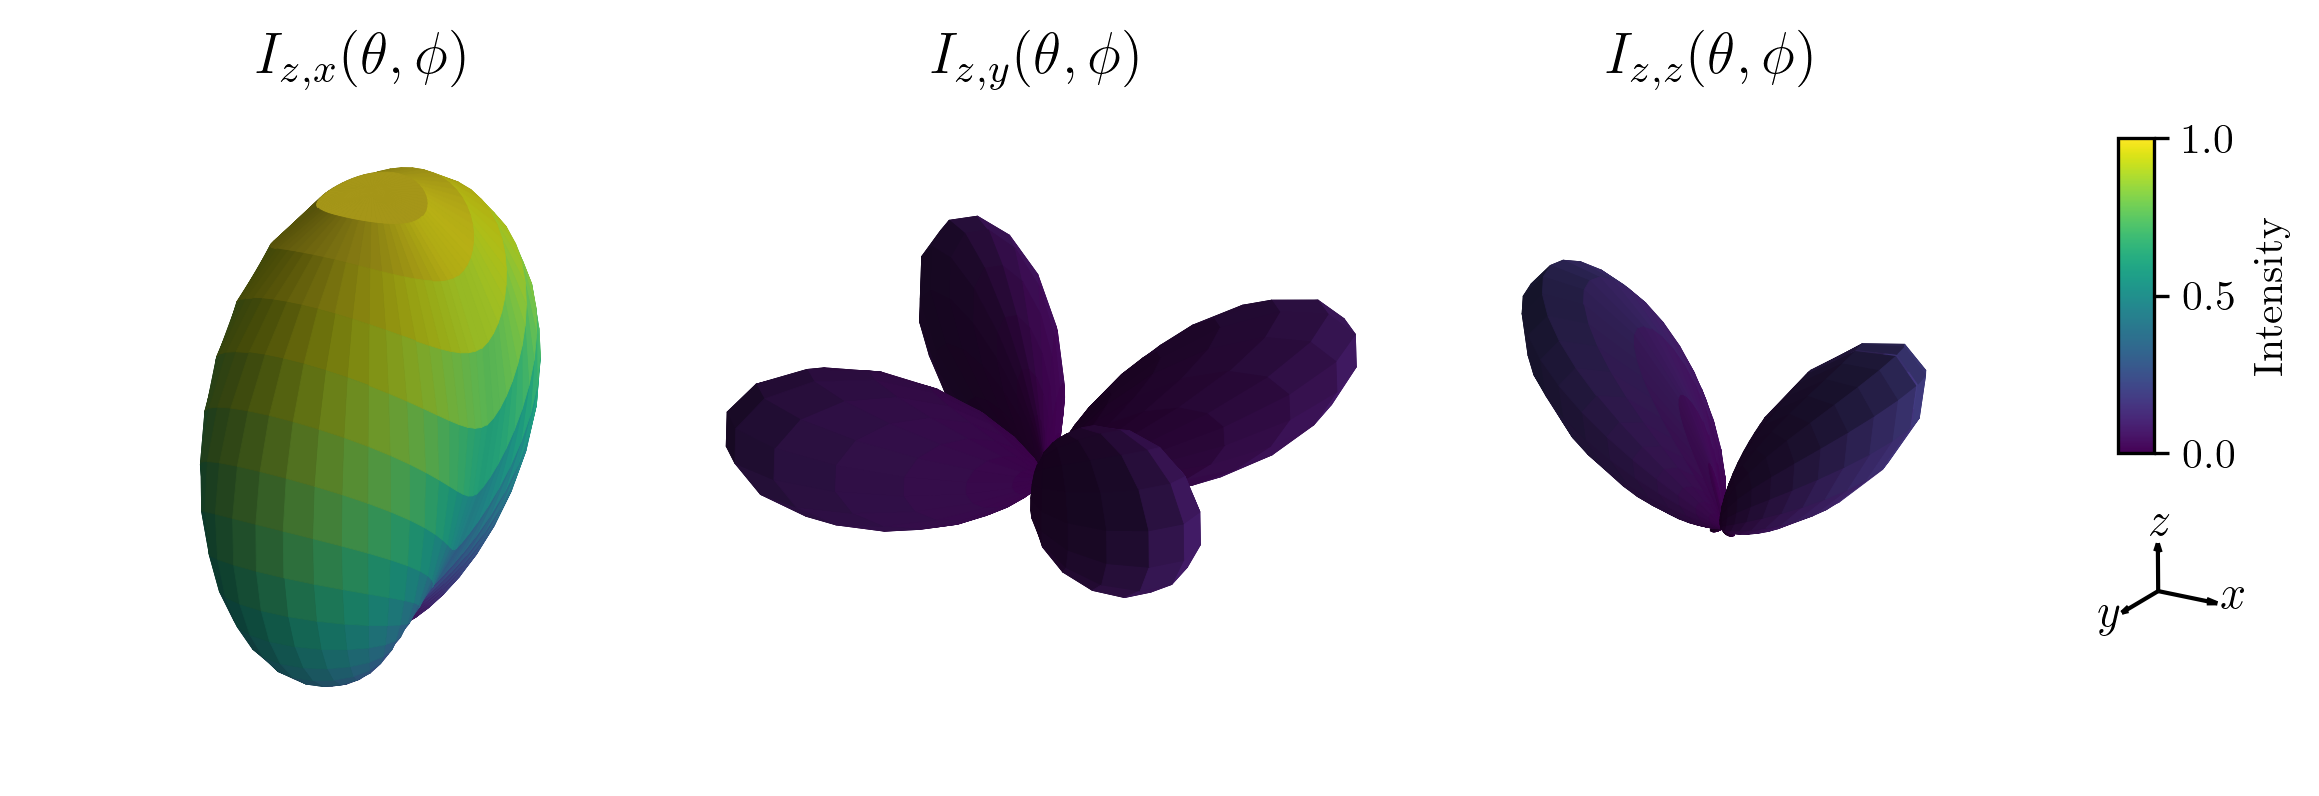

In [11]:
E_com_plus_z, E_com_minus_z, dE_com_z = com_scattered_farfield(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, axis_index=2, disp_nm=disp_nm, Nteta=Nteta, 
                                                               Nphi=Nphi, field_index=field_index, r=r)
I_com_z_total, I_com_z_Ex, I_com_z_Ey, I_com_z_Ez = info_patterns_from_scattered_field(dE=dE_com_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_z_Ex, I_com_z_Ey, I_com_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, normalize=DEFAULT_2D_NORMALIZE, 
                     fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_z_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_z_Ex, I_com_z_Ey, I_com_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, scale_list=[0.34, 0.34, 0.4], savefig=False, 
                     save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_z_3d", results_dir=results_dir)

## Total COM information patterns

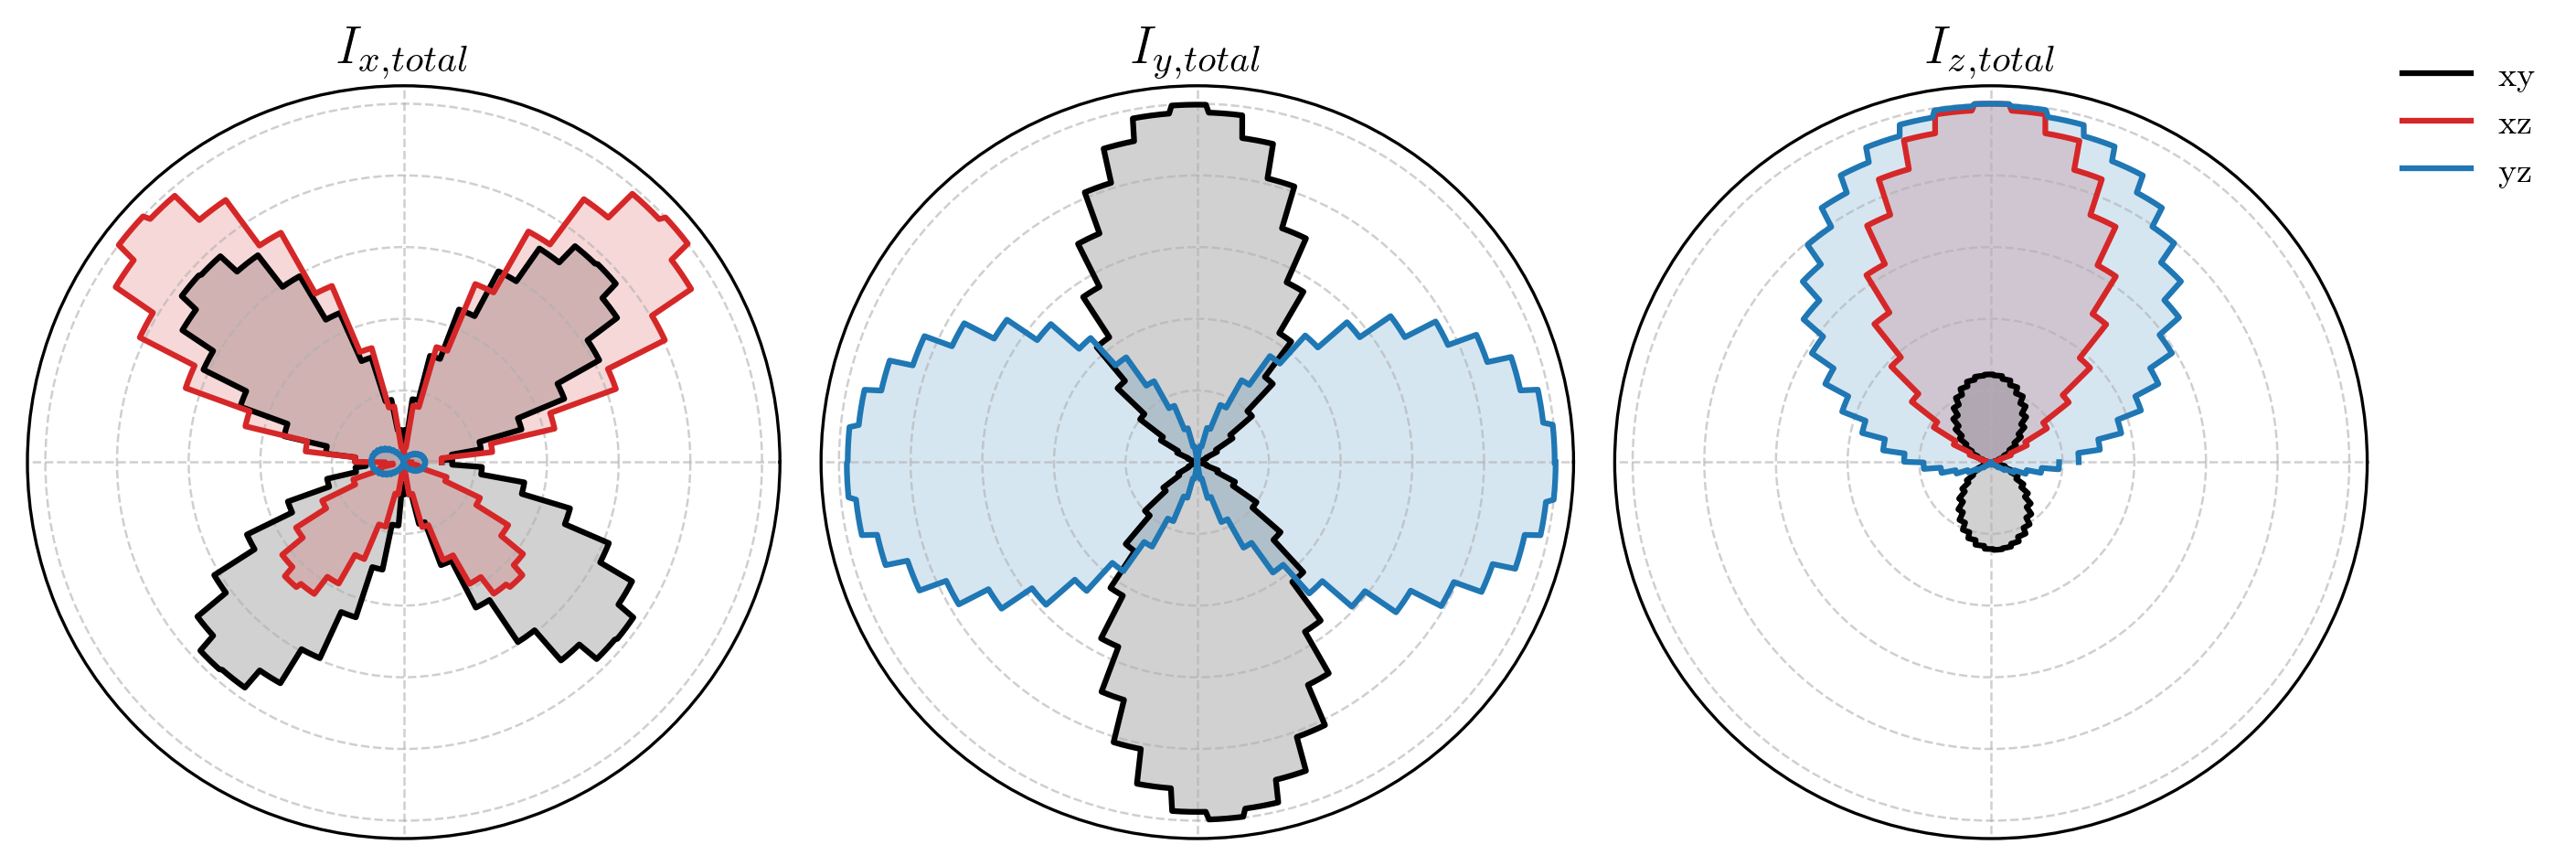

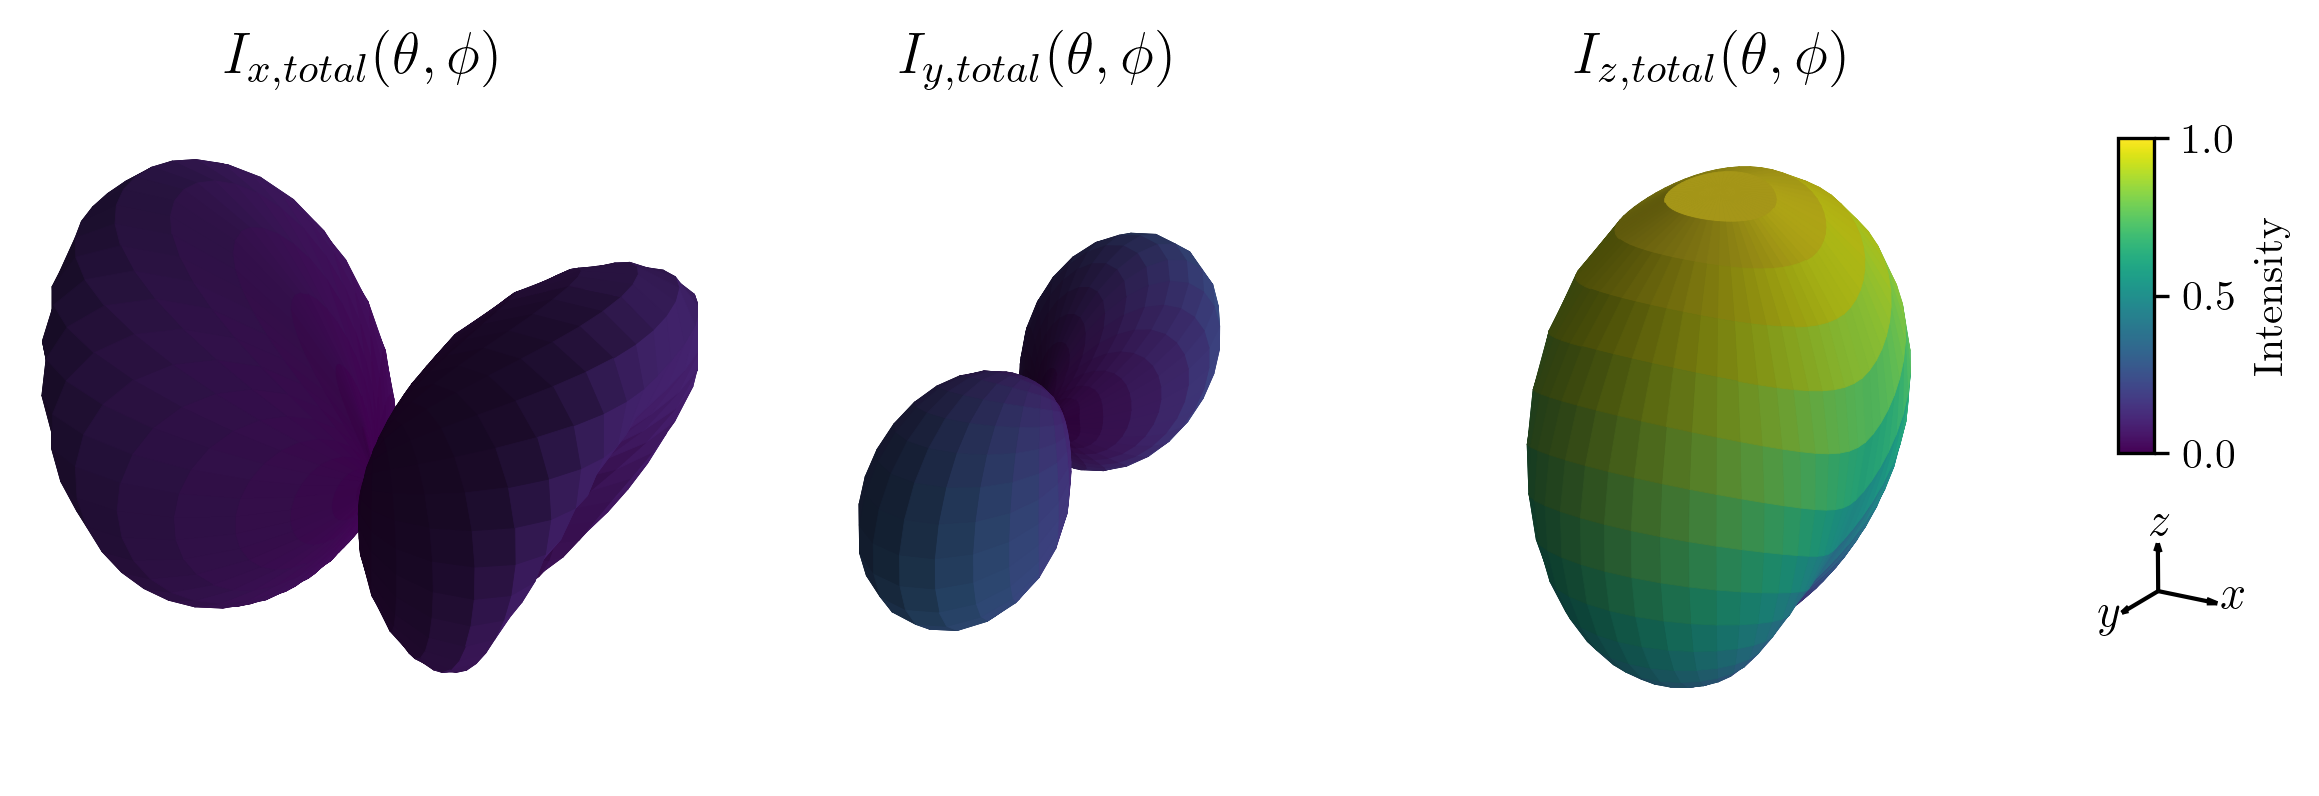

In [12]:
plot2d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_total, I_com_y_total, I_com_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_total_2d", results_dir=results_dir)
plot3d_info_patterns(Nteta=Nteta, Nphi=Nphi, info_patterns=[I_com_x_total, I_com_y_total, I_com_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, scale_list=[0.28, 0.28, 0.34], 
                     savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="com_info_patterns_total_3d", results_dir=results_dir)

## Maximum detection efficiency

In [13]:
eta_lib_x = max_detection_efficiency(I_lib_x_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)
eta_lib_y = max_detection_efficiency(I_lib_y_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)
eta_lib_z = max_detection_efficiency(I_lib_z_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)

eta_com_x = max_detection_efficiency(I_com_x_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)
eta_com_y = max_detection_efficiency(I_com_y_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)
eta_com_z = max_detection_efficiency(I_com_z_total, Nteta, Nphi, PLUS_Z_HEMISPHERE_THETA_MAX)

print("Maximum detection efficiency for libration")
print(f"x: {100 * eta_lib_x:.2f} %")
print(f"y: {100 * eta_lib_y:.2f} %")
print(f"z: {100 * eta_lib_z:.2f} %")

print("\nMaximum detection efficiency for COM")
print(f"x: {100 * eta_com_x:.2f} %")
print(f"y: {100 * eta_com_y:.2f} %")
print(f"z: {100 * eta_com_z:.2f} %")

Maximum detection efficiency for libration
x: 82.44 %
y: 52.13 %
z: 49.12 %

Maximum detection efficiency for COM
x: 61.68 %
y: 49.48 %
z: 92.45 %


## Optical force vs displacement

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 140.8ms, inv.: 965.5ms, repropa.: 4825.0ms (1 field configs), tot: 5931.5ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 90.5ms, inv.: 908.4ms, repropa.: 5298.1ms (1 field configs), tot: 6297.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 89.7ms, inv.: 947.8ms, repropa.: 5015.0ms (1 field configs), tot: 6052.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 88.6ms, inv.: 964.5ms, repropa.: 4551.5ms (1 field configs), tot: 5604.8ms
structure initialization - automatic mesh detec

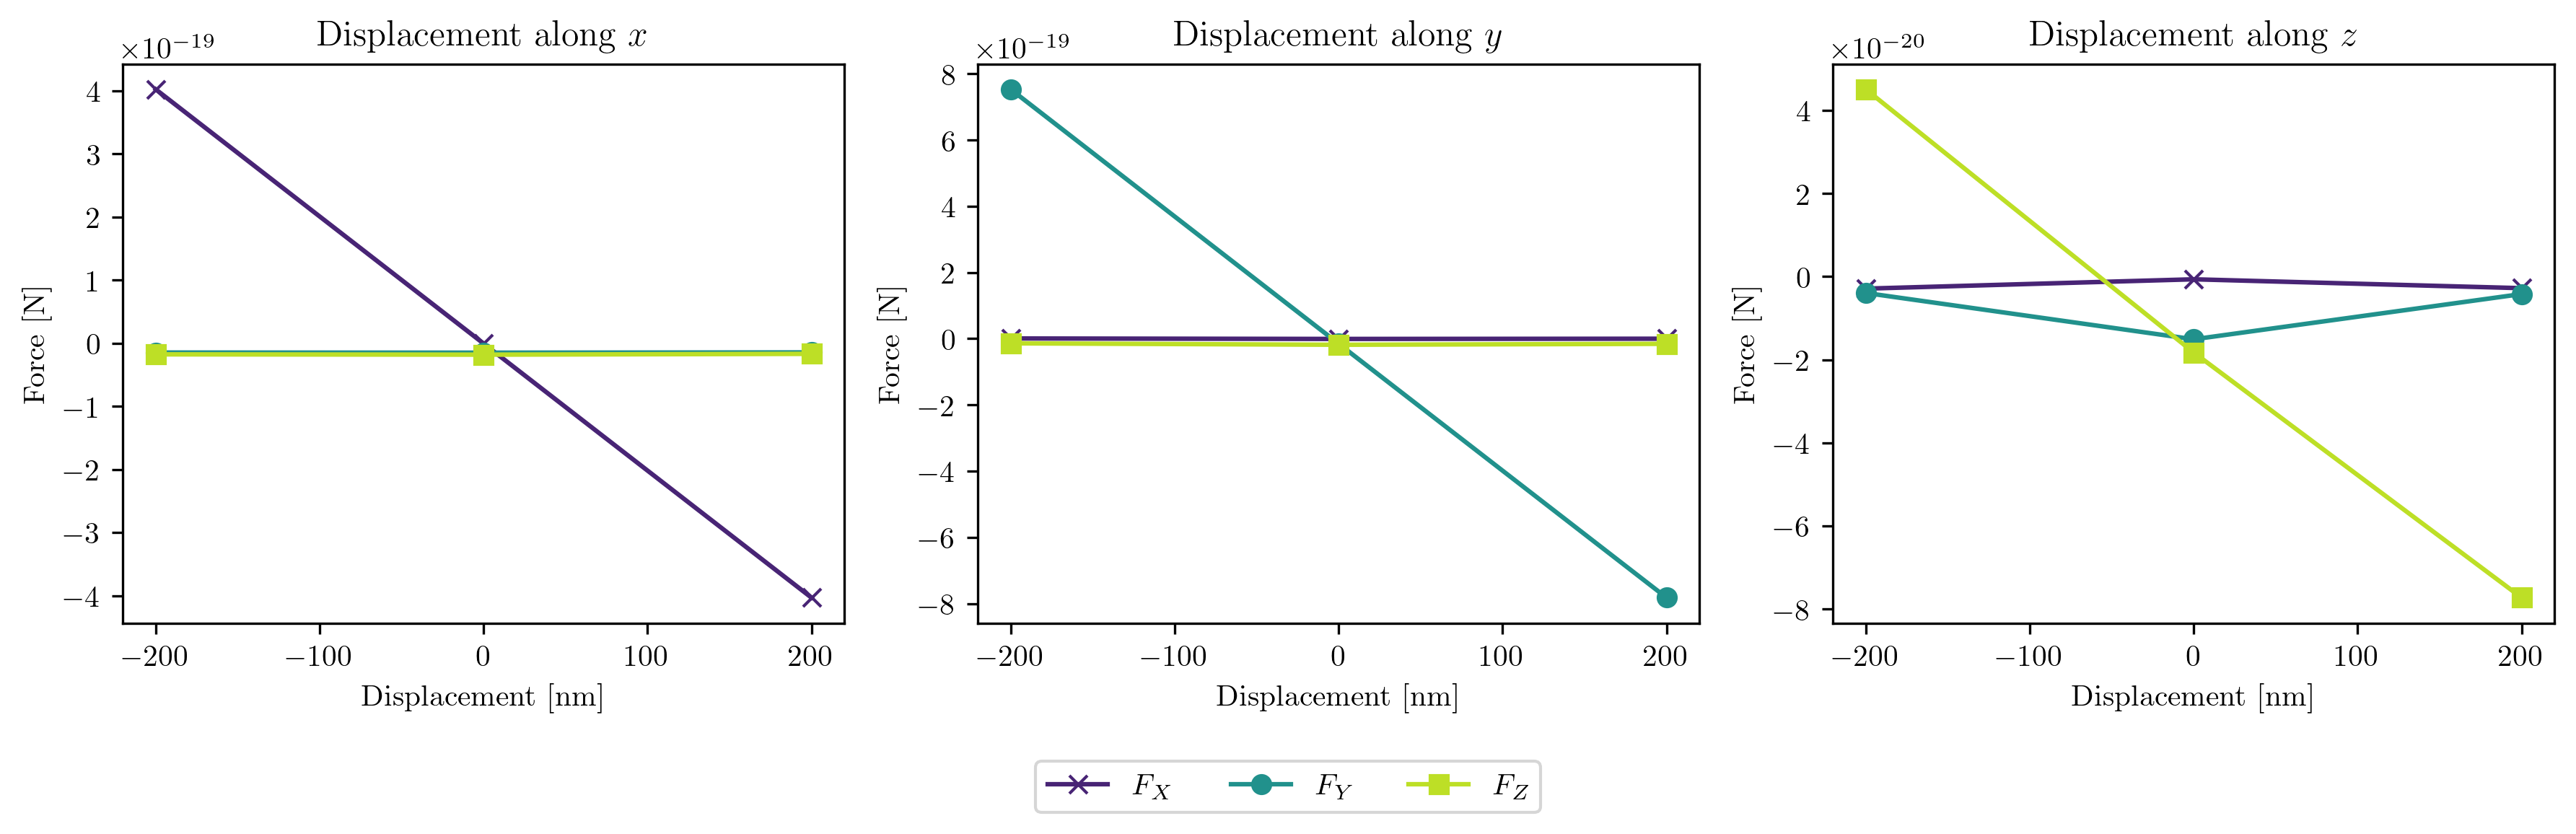

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Displacement along $x$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $y$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>,
        <Axes: title={'center': 'Displacement along $z$'}, xlabel='Displacement [nm]', ylabel='Force [N]'>],
       dtype=object))

In [14]:
Force = force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=np.array([-200.0, 0.0, 200.0]), field_index=field_index)
plot_force_displacement(displacements=np.array([-200.0, 0.0, 200.0]), Force=Force, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="force_vs_displacement", results_dir=results_dir)

## Optical torque vs rotation

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 98.0ms, inv.: 858.1ms, repropa.: 4954.0ms (1 field configs), tot: 5910.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 82.7ms, inv.: 938.6ms, repropa.: 4475.5ms (1 field configs), tot: 5496.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 82.0ms, inv.: 875.4ms, repropa.: 4441.3ms (1 field configs), tot: 5398.8ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 96.0ms, inv.: 924.9ms, repropa.: 4417.8ms (1 field configs), tot: 5438.7ms
structure initialization - automatic mesh detect

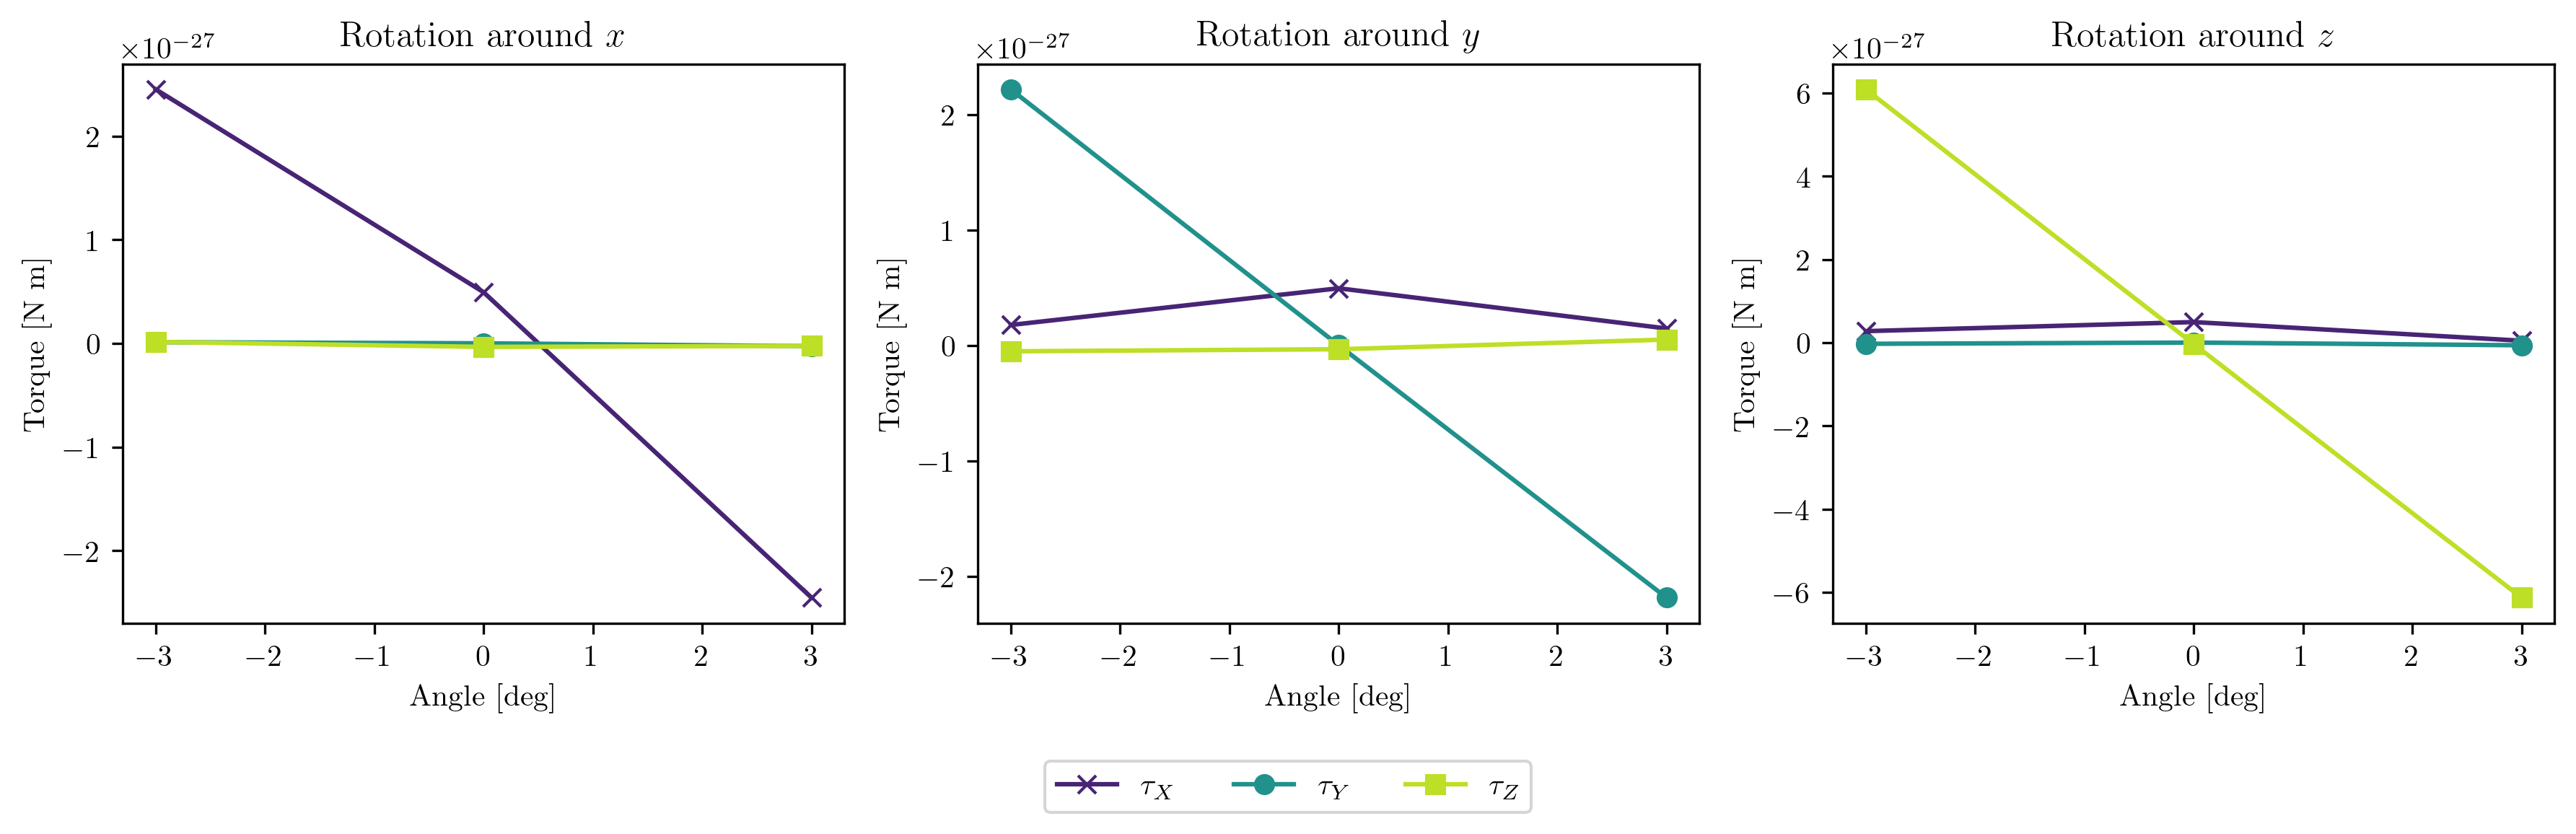

(<Figure size 3600x1140 with 3 Axes>,
 array([<Axes: title={'center': 'Rotation around $x$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $y$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>,
        <Axes: title={'center': 'Rotation around $z$'}, xlabel='Angle [deg]', ylabel='Torque [N m]'>],
       dtype=object))

In [15]:
Torque = torque_vs_rotation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, angles_deg= np.array([-3.0, 0.0, 3.0]), field_index=field_index)
plot_torque_rotation(angles_deg= np.array([-3.0, 0.0, 3.0]), Torque=Torque, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="torque_vs_rotation", results_dir=results_dir)

## Recoil heating rate

In [16]:
recoil_displacements_nm = np.array([-200.0, 0.0, 200.0])
E_scat = scattered_farfield_from_simulation(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, Nteta=Nteta, Nphi=Nphi, 
                                            field_index=field_index, r=r)
S_FF_x = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=0)
S_FF_y = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=1)
S_FF_z = recoil_force_noise_psd(E_scat=E_scat[2], wavelength_nm=wavelength_nm, Nteta=Nteta, Nphi=Nphi, r_nm=r, axis_index=2)

Force_recoil = force_vs_displacement(geometry=geometry, step_nm=step_nm, material=material, efield=efield, dyads=dyads, displacements=recoil_displacements_nm, 
                                     field_index=field_index)

Omega_x, k_x = trap_frequency(recoil_displacements_nm, Force_recoil["X"][:, 0], mass)
Omega_y, k_y = trap_frequency(recoil_displacements_nm, Force_recoil["Y"][:, 1], mass)
Omega_z, k_z = trap_frequency(recoil_displacements_nm, Force_recoil["Z"][:, 2], mass)

Gamma_x = heating_rate(S_FF_x, mass, Omega_x)
Gamma_y = heating_rate(S_FF_y, mass, Omega_y)
Gamma_z = heating_rate(S_FF_z, mass, Omega_z)

print("Mass")
print(f"m = {mass:.6e} kg")

print("\nTrap stiffness")
print(f"k_x = {k_x:.6e} N/m")
print(f"k_y = {k_y:.6e} N/m")
print(f"k_z = {k_z:.6e} N/m")

print("\nTrap frequencies")
print(f"Omega_x = {Omega_x:.6e} rad/s, f_x = {Omega_x / (2*np.pi):.6e} Hz")
print(f"Omega_y = {Omega_y:.6e} rad/s, f_y = {Omega_y / (2*np.pi):.6e} Hz")
print(f"Omega_z = {Omega_z:.6e} rad/s, f_z = {Omega_z / (2*np.pi):.6e} Hz")

print("\nRecoil force-noise PSD")
print(f"S_FF_x = {S_FF_x:.6e}")
print(f"S_FF_y = {S_FF_y:.6e}")
print(f"S_FF_z = {S_FF_z:.6e}")

print("\nRecoil heating rates")
print(f"Gamma_x = {Gamma_x:.6e} phonons/s")
print(f"Gamma_y = {Gamma_y:.6e} phonons/s")
print(f"Gamma_z = {Gamma_z:.6e} phonons/s")

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 95.4ms, inv.: 887.2ms, repropa.: 4285.9ms (1 field configs), tot: 5268.6ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 96.3ms, inv.: 937.9ms, repropa.: 4443.0ms (1 field configs), tot: 5477.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 105.2ms, inv.: 1448.2ms, repropa.: 7532.6ms (1 field configs), tot: 9086.2ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 1383/1383 dipoles valid
timing for wl=1550.00nm - setup: EE 83.2ms, inv.: 918.5ms, repropa.: 4473.8ms (1 field configs), tot: 5475.6ms
structure initialization - automatic mesh dete